# EDA regionalizado del dataset CDC BRFSS 2015
## Contextualización para IMSS / ENSANUT

---

**Propósito del notebook**  
Este cuaderno presenta un análisis exploratorio de datos orientado a evaluar la transferibilidad del dataset CDC BRFSS 2015 hacia un contexto de salud pública mexicano, tomando como referencia ENSANUT 2022 e indicadores de uso clínico compatibles con IMSS. El objetivo no es solo describir el dataset, sino identificar qué tan apropiado resulta como base para el desarrollo posterior del sistema predictivo de diabetes tipo 2.

**Enfoque de lectura**
- **Dimensión estadística:** revisar estructura, calidad, rangos, desbalance y relaciones entre variables.
- **Dimensión epidemiológica:** comparar la distribución observada con referencias mexicanas para reconocer sesgos de transferibilidad.
- **Dimensión de modelado:** derivar decisiones concretas para el preprocesamiento y la selección de estrategias de evaluación.

**Hipótesis de trabajo**  
> La muestra CDC BRFSS 2015 puede servir como base de entrenamiento para estimar riesgo de diabetes en población mexicana, siempre que se expliciten las diferencias distributivas respecto de ENSANUT y se ajuste la calibración del modelo para evitar interpretaciones clínicamente engañosas.

---

### Estructura analítica

| Bloque | Propósito | Pregunta guía |
|--------|-----------|---------------|
| 0 | Preparación del entorno | ¿El dataset y sus variables cumplen el contrato esperado? |
| 1 | Control de calidad | ¿Hay nulos, rangos inválidos o desbalance relevante? |
| 2 | Análisis univariado | ¿Qué distribuciones difieren respecto de ENSANUT? |
| 3 | Análisis bivariado | ¿Qué variables se asocian más con diabetes? |
| 4 | Contraste CDC ↔ México | ¿Dónde aparece el sesgo de transferibilidad? |
| 5 | Desbalance y remuestreo | ¿Qué estrategia es más defendible metodológicamente? |
| 6 | Síntesis final | ¿Qué decisiones quedan justificadas para el modelado? |


---
## Bloque 0 — Setup y Configuración


In [34]:
# ── Imports estándar ────────────────────────────────────────────────────────
from __future__ import annotations

import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score
from IPython.display import display, Markdown, HTML

warnings.filterwarnings('ignore')

# ── Parámetros de visualización ─────────────────────────────────────────────
# Paleta clínica: verde IMSS para positivos, grises para negativos
COLOR_POSITIVO   = '#006847'   # verde institucional IMSS
COLOR_NEGATIVO   = '#B0BEC5'   # gris neutro
COLOR_ADVERTENCIA = '#F9A825'  # ámbar para alertas
COLOR_PELIGRO    = '#C62828'   # rojo para riesgo alto
PALETA_RIESGO    = [COLOR_NEGATIVO, COLOR_PELIGRO]

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'font.family': 'sans-serif',
})
sns.set_style('whitegrid')

# ── Ruta al dataset ─────────────────────────────────────────────────────────
# Ajusta RUTA_BASE a la raíz de tu repositorio local si es necesario
RUTA_BASE    = Path('../')   # relativo al directorio notebooks/
RUTA_DATASET = RUTA_BASE / 'datos' / 'brutos' / 'diabetes_binary_health_indicators_BRFSS2015.csv'

# Fallback: busca en el directorio del proyecto si existe
if not RUTA_DATASET.exists():
    RUTA_DATASET = Path('/mnt/project/diabetes_binary_health_indicators_BRFSS2015.csv')

# ── Constantes del dominio CDC ───────────────────────────────────────────────
COLUMNAS_CDC = (
    'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
    'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
)
COLUMNA_OBJETIVO = 'Diabetes_binary'

COLUMNAS_BINARIAS = [
    'HighBP','HighChol','CholCheck','Smoker','Stroke','HeartDiseaseorAttack',
    'PhysActivity','Fruits','Veggies','HvyAlcoholConsump','AnyHealthcare',
    'NoDocbcCost','DiffWalk','Sex',
]
COLUMNAS_CONTINUAS  = ['BMI', 'MentHlth', 'PhysHlth']
COLUMNAS_ORDINALES  = ['GenHlth', 'Age', 'Education', 'Income']

# ── Prevalencias ENSANUT 2022 (referencia para contraste regional) ───────────
# Fuente: Encuesta Nacional de Salud y Nutrición 2022 (INSP)
ENSANUT_REFS = {
    'HighBP'              : 0.301,   # 30.1% adultos ≥20 años
    'HighChol'            : 0.196,   # 19.6% adultos
    'Smoker'              : 0.176,   # 17.6% prevalencia tabaquismo
    'PhysActivity'        : 0.605,   # complemento de 39.5% inactivos
    'Fruits'              : 0.420,   # 42% consume fruta diariamente
    'Veggies'             : 0.340,   # 34% consume verdura diariamente
    'HvyAlcoholConsump'   : 0.076,   # consumo excesivo (ENCODAT)
}

# IMC medio esperado en población mexicana adulta (ENSANUT)
BMI_MEDIA_MEXICO = 29.2   # kg/m²  — distribución desplazada ~+1.5 vs CDC

# Mensajes de contexto para formato; se muestran en una celda separada
setup_contexto = [
    f'**Dataset en:** {RUTA_DATASET}',
    f'**Archivo existe:** {RUTA_DATASET.exists()}',
    '**Setup completado.** El cuaderno quedó preparado para leer el dataset y construir el EDA de forma reproducible.',
]

### Formato del Bloque 0

Este bloque solo muestra el contexto inicial del cuaderno; la lógica de preparación quedó en la celda anterior para separar ejecución y presentación.

In [35]:
from IPython.display import Markdown, display

for texto in setup_contexto:
    display(Markdown(texto))

**Dataset en:** ..\datos\brutos\diabetes_binary_health_indicators_BRFSS2015.csv

**Archivo existe:** True

**Setup completado.** El cuaderno quedó preparado para leer el dataset y construir el EDA de forma reproducible.

---
## Bloque 1. Carga y contrato de calidad

### Objetivo metodológico
Verificar que el dataset cumpla con el contrato esperado antes de cualquier análisis posterior. En un contexto clínico, un valor ausente o un rango inválido no es un detalle menor: puede alterar la lectura del riesgo y comprometer la interpretación del modelo.

### Criterios de revisión
Este bloque examina tres aspectos básicos: integridad de columnas, ausencia de valores faltantes y plausibilidad clínica de los rangos. La intención es asegurar que las etapas posteriores trabajen sobre una base consistente y reproducible.


In [88]:
# ── 1.1-1.3  Carga, contrato y auditoría de nulos ─────────────────────────
df = pd.read_csv(RUTA_DATASET)

resumen_carga = pd.DataFrame([
    {'Indicador': 'Filas', 'Valor': f'{df.shape[0]:,}'},
    {'Indicador': 'Columnas', 'Valor': f'{df.shape[1]}'},
    {'Indicador': 'Memoria consumida', 'Valor': f'{df.memory_usage(deep=True).sum() / 1e6:.1f} MB'},
])

columnas_esperadas = list(COLUMNAS_CDC) + [COLUMNA_OBJETIVO]
columnas_presentes = list(df.columns)
faltantes = [c for c in columnas_esperadas if c not in columnas_presentes]
extras = [c for c in columnas_presentes if c not in columnas_esperadas]
orden_ok = list(df.columns[:21]) == list(COLUMNAS_CDC)

resumen_columnas = pd.DataFrame([
    {'Chequeo': 'Columnas esperadas', 'Resultado': len(columnas_esperadas)},
    {'Chequeo': 'Columnas presentes', 'Resultado': len(columnas_presentes)},
    {'Chequeo': 'Faltantes', 'Resultado': ', '.join(faltantes) if faltantes else 'ninguna'},
    {'Chequeo': 'Adicionales', 'Resultado': ', '.join(extras) if extras else 'ninguna'},
    {'Chequeo': 'Orden CDC correcto', 'Resultado': 'Sí' if orden_ok else 'No'},
])

nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100
reporte_nulos = pd.DataFrame({
    'n_nulos'  : nulos,
    'pct_nulos': pct_nulos.round(2),
}).sort_values('n_nulos', ascending=False)

heatmap_nulos = df.isnull().mean().to_frame().T

### Formato del Bloque 1

En esta sección se muestran la carga del dataset, el contrato de columnas y la auditoría de nulos. La celda anterior se reservó para el cálculo; esta celda se reserva para la presentación.

#### Carga del dataset

Indicador,Valor
Filas,"253,680"
Columnas,22
Memoria consumida,44.6 MB


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0


#### Contrato de columnas

Chequeo,Resultado
Columnas esperadas,22
Columnas presentes,22
Faltantes,ninguna
Adicionales,ninguna
Orden CDC correcto,Sí


#### Auditoría de valores faltantes

No se detectaron valores faltantes en ninguna columna. El dataset conserva un contrato limpio para el análisis exploratorio y no requiere imputación en esta etapa.

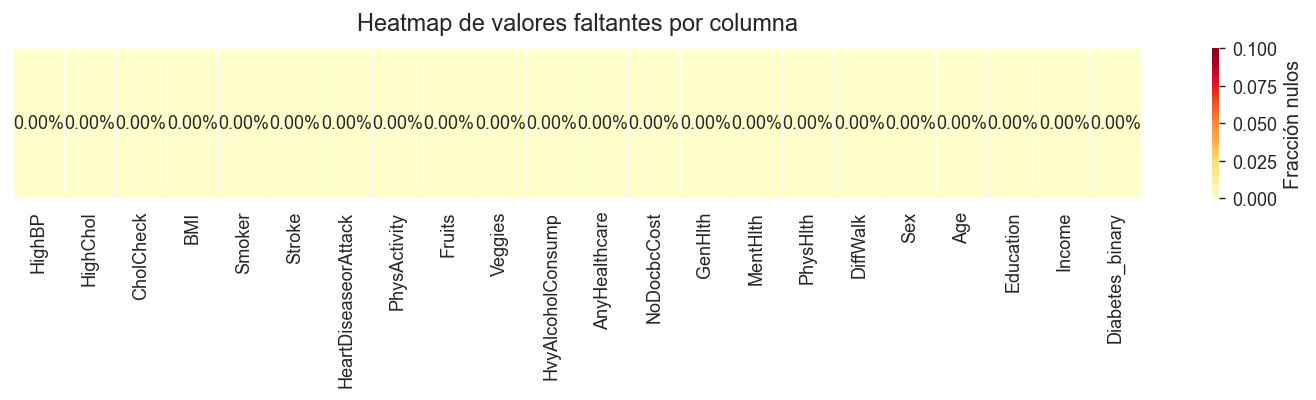

In [37]:
display(Markdown('#### Carga del dataset'))
display(resumen_carga.style.hide(axis='index'))
display(df.head(3))
display(Markdown('#### Contrato de columnas'))
display(resumen_columnas.style.hide(axis='index'))
display(Markdown('#### Auditoría de valores faltantes'))
if reporte_nulos['n_nulos'].sum() == 0:
    display(Markdown('No se detectaron valores faltantes en ninguna columna. El dataset conserva un contrato limpio para el análisis exploratorio y no requiere imputación en esta etapa.'))
else:
    display(reporte_nulos[reporte_nulos['n_nulos'] > 0].style.hide(axis='index'))
fig, ax = plt.subplots(figsize=(14, 1.5))
sns.heatmap(heatmap_nulos, ax=ax, cmap='YlOrRd', vmin=0, vmax=0.1, linewidths=0.5, annot=True, fmt='.2%', cbar_kws={'label': 'Fracción nulos'})
ax.set_title('Heatmap de valores faltantes por columna', pad=10)
ax.set_yticklabels([''], rotation=0)
plt.tight_layout()
plt.show()

In [38]:
# ── 1.4  Verificación de rangos clínicos plausibles ─────────────────────────
# Las variables binarias deben contener únicamente 0 y 1
# Las ordinales deben estar dentro de sus escalas CDC documentadas
RANGOS_ESPERADOS = {
    **{col: (0, 1)         for col in COLUMNAS_BINARIAS},
    'BMI'      : (10, 98),
    'GenHlth'  : (1, 5),
    'MentHlth' : (0, 30),
    'PhysHlth' : (0, 30),
    'Age'      : (1, 13),
    'Education': (1, 6),
    'Income'   : (1, 8),
    COLUMNA_OBJETIVO: (0, 1),
}

violaciones = []
for col, (vmin, vmax) in RANGOS_ESPERADOS.items():
    fuera = ((df[col] < vmin) | (df[col] > vmax)).sum()
    if fuera > 0:
        violaciones.append({'columna': col, 'fuera_de_rango': fuera,
                            'min_obs': df[col].min(), 'max_obs': df[col].max()})

resumen_estadistico = df.describe().round(2)

### Formato del Bloque 1.4

La celda anterior verifica rangos clínicos; esta celda muestra el resultado y el resumen estadístico general.

In [39]:
display(Markdown('#### Verificación de rangos clínicos'))
if not violaciones:
    display(Markdown('No se observaron violaciones de rango en las variables revisadas. El dataset cumple con los límites clínicos esperados.'))
else:
    display(pd.DataFrame(violaciones).style.hide(axis='index'))

display(Markdown('#### Resumen estadístico general'))
display(resumen_estadistico)

#### Verificación de rangos clínicos

No se observaron violaciones de rango en las variables revisadas. El dataset cumple con los límites clínicos esperados.

#### Resumen estadístico general

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,...,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
mean,0.43,0.42,0.96,28.38,0.44,0.04,0.09,0.76,0.63,0.81,...,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05,0.14
std,0.49,0.49,0.19,6.61,0.50,0.20,0.29,0.43,0.48,0.39,...,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07,0.35
min,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00
25%,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,1.00,...,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00,0.00
50%,0.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,1.00,...,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00,0.00
75%,1.00,1.00,1.00,31.00,1.00,0.00,0.00,1.00,1.00,1.00,...,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00,0.00
max,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00,1.00


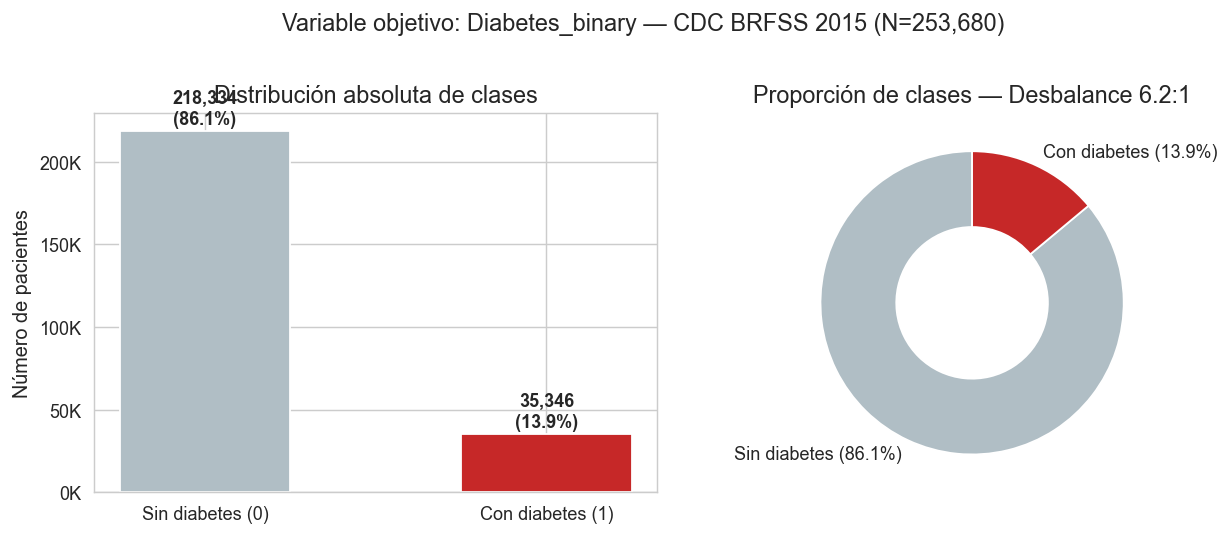

In [40]:
# ── 1.5  Distribución de la variable objetivo ────────────────────────────────
conteos = df[COLUMNA_OBJETIVO].value_counts().sort_index()
n_total = len(df)
pct_clase0 = conteos[0] / n_total
pct_clase1 = conteos[1] / n_total
ratio_desbalance = conteos[0] / conteos[1]

resumen_objetivo = pd.DataFrame([
    {'Clase': 'Sin diabetes (0)', 'Casos': conteos[0], 'Proporción': f'{pct_clase0:.1%}'},
    {'Clase': 'Con diabetes (1)', 'Casos': conteos[1], 'Proporción': f'{pct_clase1:.1%}'},
])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Barras absolutas
axes[0].bar(['Sin diabetes (0)', 'Con diabetes (1)'],
            conteos.values, color=PALETA_RIESGO, edgecolor='white', width=0.5)
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 2000, f'{v:,}\n({v/n_total:.1%})',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Distribución absoluta de clases')
axes[0].set_ylabel('Número de pacientes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Donut chart proporcional
axes[1].pie(
    conteos.values,
    labels=['Sin diabetes (86.1%)', 'Con diabetes (13.9%)'],
    colors=PALETA_RIESGO,
    wedgeprops={'width': 0.5, 'edgecolor': 'white'},
    startangle=90,
    textprops={'fontsize': 10},
)
axes[1].set_title('Proporción de clases — Desbalance 6.2:1')

plt.suptitle('Variable objetivo: Diabetes_binary — CDC BRFSS 2015 (N=253,680)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Hallazgos del Bloque 1

| Dimensión | Resultado observado | Lectura metodológica |
|-----------|---------------------|----------------------|
| Valores faltantes | 0 nulos en las 22 columnas | No se requiere imputación para el conjunto de entrenamiento. |
| Contrato de columnas | 21 variables CDC + objetivo presentes | La estructura es compatible con el pipeline previsto. |
| Rangos clínicos | No se detectaron violaciones | El dataset cumple el contrato de entrada esperado. |
| Desbalance de clases | 6.2:1 (86.1% vs. 13.9%) | La sensibilidad debe priorizarse por encima de la accuracy. |
| Prevalencia de diabetes | 13.9% | La magnitud es cercana a ENSANUT 2022 y permite usar el dataset como proxy inicial. |

El bloque deja un punto claro para el resto del notebook: el dataset es consistente, pero la clase positiva es minoritaria y cualquier métrica global debe interpretarse con cautela.

---
## Bloque 2. Análisis univariado con referencia ENSANUT

### Objetivo metodológico
Explorar la distribución de cada variable por separado y compararla con referencias mexicanas cuando existan. Este ejercicio permite distinguir entre variables que representan características relativamente estables y variables cuyo comportamiento cambia de forma importante al trasladar el análisis a otra población.

### Criterio de lectura
Las comparaciones visuales se interpretan como señales de transferibilidad o sesgo distribucional. La relevancia no está solo en la magnitud de la diferencia, sino en su posible impacto sobre la calibración y la equidad del modelo.


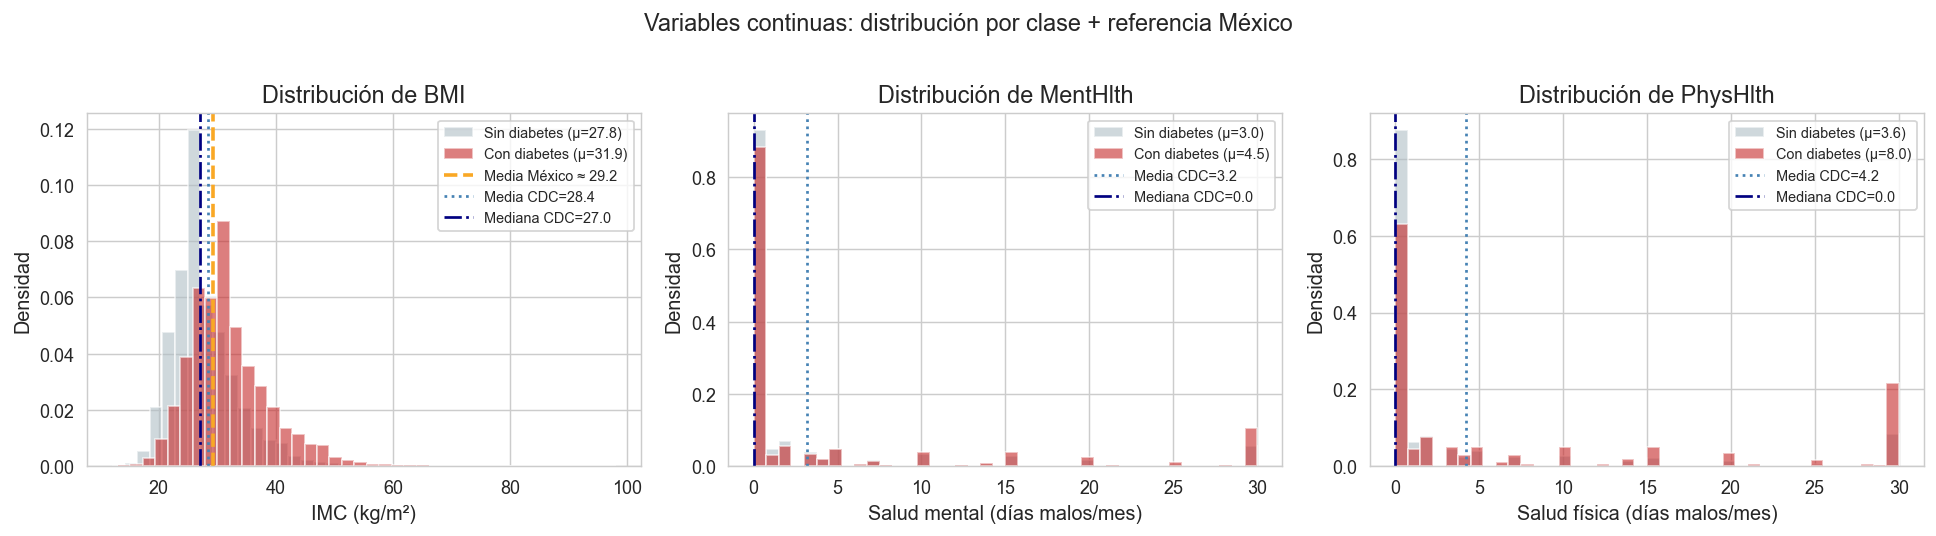

#### Estadísticos descriptivos de variables continuas

,BMI,MentHlth,PhysHlth
count,253680.000,253680.000,253680.000
mean,28.380,3.180,4.240
std,6.610,7.410,8.720
min,12.000,0.000,0.000
25%,24.000,0.000,0.000
50%,27.000,0.000,0.000
75%,31.000,2.000,3.000
max,98.000,30.000,30.000
skewness,2.122,2.721,2.207
kurtosis,10.997,6.442,3.496


**Lectura rápida:** el IMC muestra un desplazamiento respecto a la media mexicana de referencia, mientras que MentHlth y PhysHlth conservan distribuciones asimétricas que justifican un escalado cuidadoso.

In [41]:
# ── 2.1  Distribución de variables continuas con línea ENSANUT ───────────────
# BMI es la variable continua más crítica: su distribución determina si el
# StandardScaler del preprocesador producirá representaciones transferibles

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vars_continuas_config = [
    ('BMI',      'IMC (kg/m²)',    BMI_MEDIA_MEXICO,    'Media México ≈ 29.2'),
    ('MentHlth', 'Salud mental (días malos/mes)', None,  None),
    ('PhysHlth', 'Salud física (días malos/mes)', None,  None),
]

for ax, (col, xlabel, ref_mx, ref_label) in zip(axes, vars_continuas_config):
    # Histograma con separación por clase
    for clase, color, label in [(0, COLOR_NEGATIVO, 'Sin diabetes'),
                                  (1, COLOR_PELIGRO, 'Con diabetes')]:
        subset = df[df[COLUMNA_OBJETIVO] == clase][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label=f'{label} (μ={subset.mean():.1f})', density=True)
    
    # Línea de referencia mexicana
    if ref_mx is not None:
        ax.axvline(ref_mx, color=COLOR_ADVERTENCIA, ls='--', lw=2, label=ref_label)
    
    # Mediana y media de la muestra completa
    ax.axvline(df[col].mean(),   color='steelblue', ls=':',  lw=1.5,
               label=f'Media CDC={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='navy',      ls='-.', lw=1.5,
               label=f'Mediana CDC={df[col].median():.1f}')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Densidad')
    ax.set_title(f'Distribución de {col}')
    ax.legend(fontsize=8)

plt.suptitle('Variables continuas: distribución por clase + referencia México',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Análisis de asimetría ────────────────────────────────────────────────────
desc = df[COLUMNAS_CONTINUAS].describe().round(2)
skew = df[COLUMNAS_CONTINUAS].skew().round(3)
kurt = df[COLUMNAS_CONTINUAS].kurtosis().round(3)
desc.loc['skewness'] = skew
desc.loc['kurtosis'] = kurt
display(Markdown('#### Estadísticos descriptivos de variables continuas'))
display(desc)
display(Markdown('**Lectura rápida:** el IMC muestra un desplazamiento respecto a la media mexicana de referencia, mientras que MentHlth y PhysHlth conservan distribuciones asimétricas que justifican un escalado cuidadoso.'))

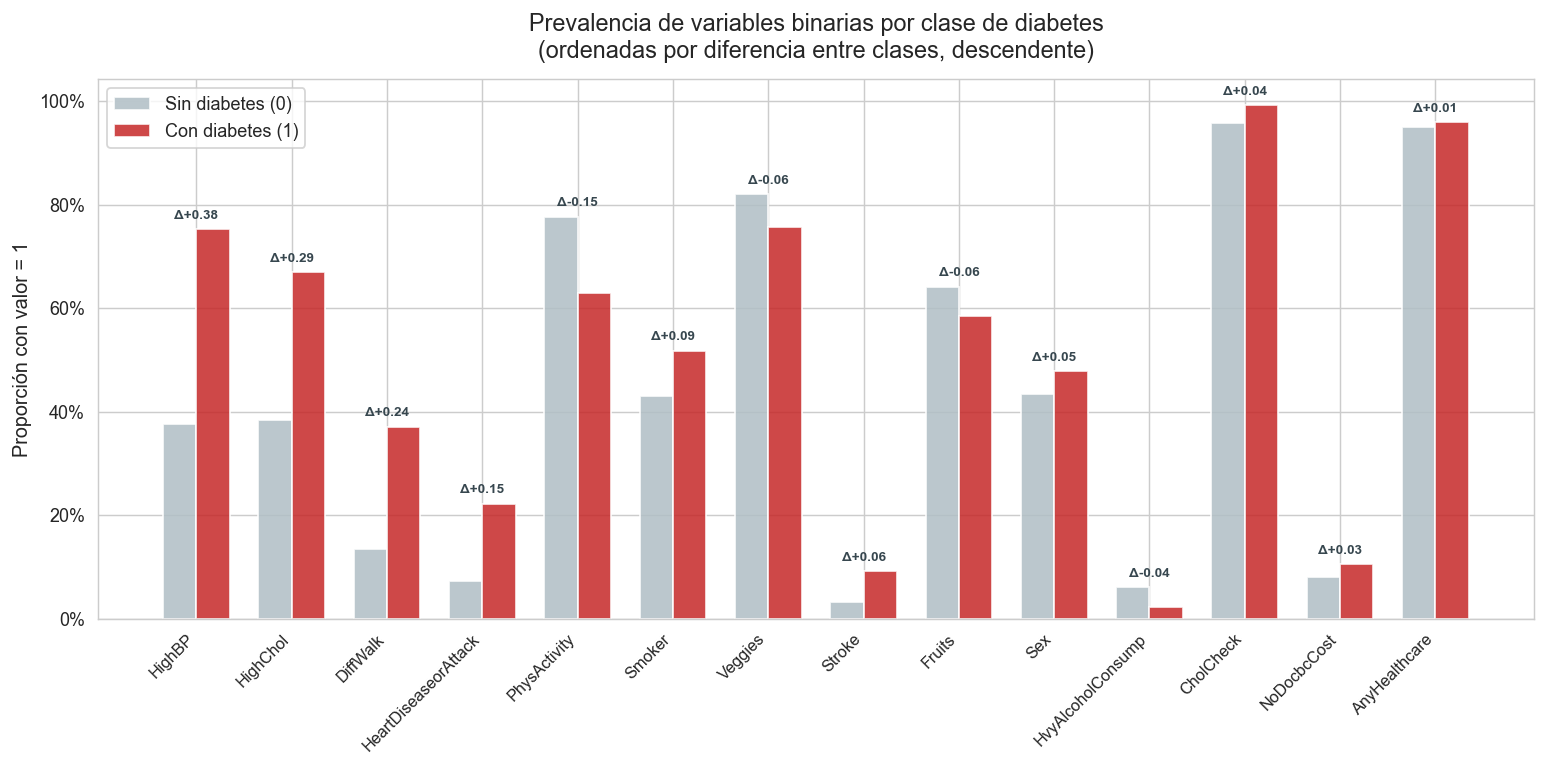

In [42]:
# ── 2.2  Distribución de variables binarias: barplot por clase ───────────────
# Visualiza la diferencia de prevalencia entre diabéticos y no diabéticos
# para detectar qué variables binarias son discriminativas clínicamente

# Calcular prevalencia de "1" por clase
prev_clase0 = df[df[COLUMNA_OBJETIVO]==0][COLUMNAS_BINARIAS].mean()
prev_clase1 = df[df[COLUMNA_OBJETIVO]==1][COLUMNAS_BINARIAS].mean()
delta_prev  = (prev_clase1 - prev_clase0).abs().sort_values(ascending=False)

# Ordenar por delta para énfasis visual en discriminación
orden_vars = delta_prev.index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(orden_vars))
width = 0.35

bars0 = ax.bar(x - width/2, prev_clase0[orden_vars], width,
               label='Sin diabetes (0)', color=COLOR_NEGATIVO, alpha=0.85)
bars1 = ax.bar(x + width/2, prev_clase1[orden_vars], width,
               label='Con diabetes (1)', color=COLOR_PELIGRO,  alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(orden_vars, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Proporción con valor = 1')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Prevalencia de variables binarias por clase de diabetes\n'
             '(ordenadas por diferencia entre clases, descendente)', pad=12)
ax.legend()

# Anotación de delta sobre cada par
for i, col in enumerate(orden_vars):
    d = prev_clase1[col] - prev_clase0[col]
    ax.annotate(f'Δ{d:+.2f}', xy=(i, max(prev_clase0[col], prev_clase1[col]) + 0.02),
                ha='center', fontsize=7.5, color='#37474F', fontweight='bold')

plt.tight_layout()
plt.show()

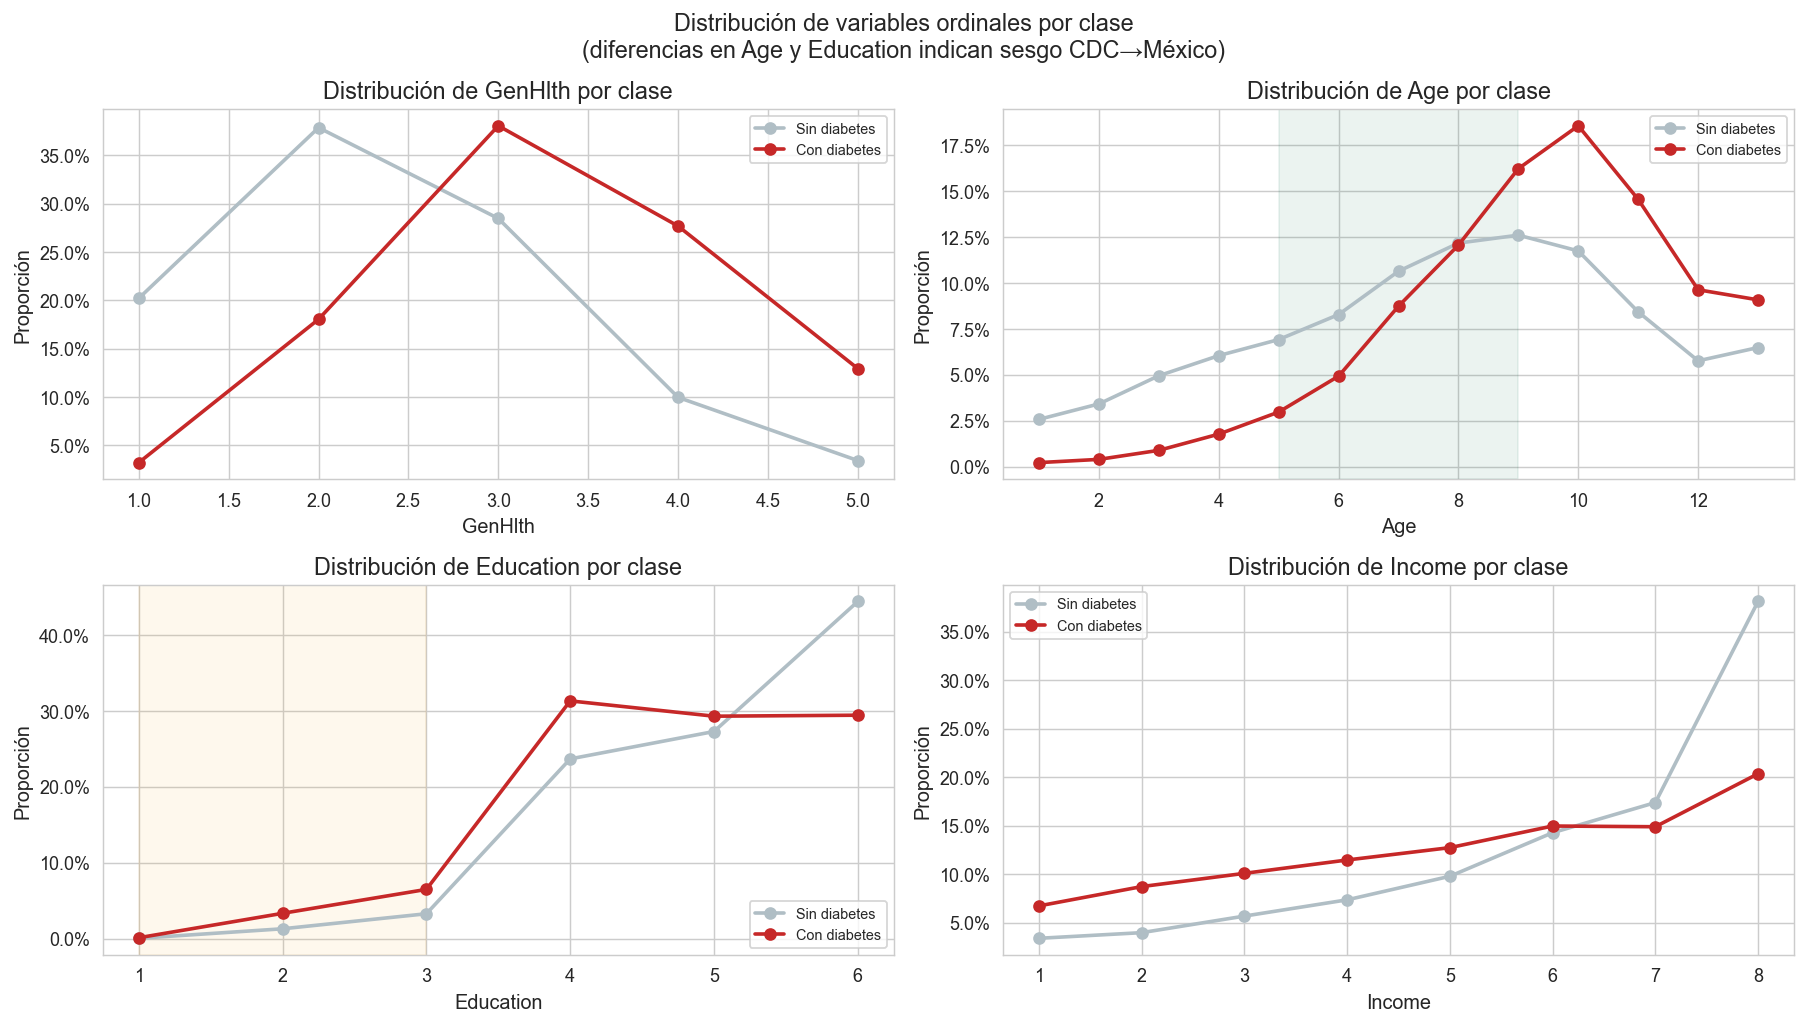

#### Lectura crítica de escolaridad

Referencia,Indicador,Proporción
CDC BRFSS,Escolaridad baja o menor,5.4%
México,Escolaridad baja o menor,24.0%


La muestra mexicana de referencia concentra una proporción mayor de escolaridad baja, por lo que la variable `Education` debe interpretarse como un factor de transferibilidad y no solo como un predictor más.

In [43]:
# ── 2.3  Distribución de variables ordinales ─────────────────────────────────
# Las ordinales son críticas para el OrdinalEncoder del preprocesador;
# identificar distribuciones asimétricas alerta sobre posibles valores
# infrecuentes que el encoder debe manejar con handle_unknown

etiquetas_ordinal = {
    'GenHlth'  : {1:'Excelente', 2:'Muy buena', 3:'Buena', 4:'Regular', 5:'Mala'},
    'Age'      : {i: f'{18+5*(i-1)}-{22+5*(i-1)}' if i < 13 else '80+'
                  for i in range(1, 14)},
    'Education': {1:'Sin escolaridad', 2:'Primaria inc.', 3:'Primaria',
                  4:'Secundaria',      5:'Preparatoria',  6:'Universidad+'},
    'Income'   : {i: f'Nivel {i}' for i in range(1, 9)},
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, COLUMNAS_ORDINALES):
    for clase, color, label in [(0, COLOR_NEGATIVO, 'Sin diabetes'),
                                  (1, COLOR_PELIGRO,  'Con diabetes')]:
        subset = df[df[COLUMNA_OBJETIVO]==clase][col].value_counts(normalize=True).sort_index()
        ax.plot(subset.index, subset.values, marker='o', color=color, label=label, lw=2)
    
    ax.set_xlabel(col)
    ax.set_ylabel('Proporción')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(f'Distribución de {col} por clase')
    ax.legend(fontsize=8)
    
    # Marcar el rango de referencia mexicana para Age y Education
    if col == 'Age':
        ax.axvspan(5, 9, alpha=0.08, color=COLOR_POSITIVO,
                   label='Grupo 40-64 (mayor carga ENSANUT)')
    if col == 'Education':
        ax.axvspan(1, 3, alpha=0.08, color=COLOR_ADVERTENCIA,
                   label='Escolaridad baja (24% México vs 2% CDC)')

plt.suptitle('Distribución de variables ordinales por clase\n'
             '(diferencias en Age y Education indican sesgo CDC→México)',
             fontsize=13)
plt.tight_layout()
plt.show()

# Análisis crítico de Education
pct_edu_baja_cdc    = (df['Education'] <= 3).mean()
pct_edu_baja_mexico = 0.24   # INEGI 2020: 24% sin educación básica completa
resumen_edu = pd.DataFrame([
    {'Referencia': 'CDC BRFSS', 'Indicador': 'Escolaridad baja o menor', 'Proporción': f'{pct_edu_baja_cdc:.1%}'},
    {'Referencia': 'México', 'Indicador': 'Escolaridad baja o menor', 'Proporción': f'{pct_edu_baja_mexico:.1%}'},
])
display(Markdown('#### Lectura crítica de escolaridad'))
display(resumen_edu.style.hide(axis='index'))
display(Markdown(f'La muestra mexicana de referencia concentra una proporción mayor de escolaridad baja, por lo que la variable `Education` debe interpretarse como un factor de transferibilidad y no solo como un predictor más.'))

### Hallazgos del Bloque 2

La comparación univariada deja tres señales claras: el IMC está desplazado hacia la zona de sobrepeso/obesidad, `Education` refleja un contraste fuerte con la referencia mexicana y las variables continuas `MentHlth` y `PhysHlth` conservan una asimetría marcada. En términos prácticos, esto confirma que el dataset es útil para modelado, pero no puede leerse como un espejo directo de la población mexicana.

La lectura crítica de `Education` es especialmente importante: la tabla ejecutada en la celda anterior muestra que la proporción de escolaridad baja es mucho mayor en la referencia mexicana, por lo que esta variable debe tratarse como un factor de transferibilidad y no solo como un predictor más.

In [44]:
from IPython.display import Markdown, display

comparativo = []
for var, ref_mx in ENSANUT_REFS.items():
    prev_cdc = float(df[var].mean())
    sesgo_pct = abs(prev_cdc - ref_mx) / ref_mx * 100 if ref_mx else 0
    comparativo.append((var, prev_cdc, ref_mx, sesgo_pct))

comparativo = sorted(comparativo, key=lambda x: x[3], reverse=True)

lineas = [
    '### Lectura rápida del contraste CDC ↔ México',
    '',
    '- Las variables con mayor sesgo relativo son las que más pueden desplazar la calibración del modelo cuando se use fuera del contexto CDC.',
    '- En este bloque, las diferencias más marcadas se concentran en factores de comportamiento y contexto social, no solo en biomarcadores.',
    '- Esto confirma que el EDA no debe quedarse en la prevalencia de diabetes: también debe revisar cómo cambian los insumos clínicos y sociales entre poblaciones.',
    '',
    '**Tres variables más sesgadas:**',
]

for var, prev_cdc, ref_mx, sesgo_pct in comparativo[:3]:
    lineas.append(f'- **{var}**: CDC {prev_cdc:.1%} vs México {ref_mx:.1%} ({sesgo_pct:.0f}%)')

lineas += [
    '',
    '> **Implicación práctica:** si el modelo se despliega para población mexicana, conviene revisar umbrales, calibración y sensibilidad por subgrupos antes de usarlo como apoyo clínico.',
]

display(Markdown('\n'.join(lineas)))

### Lectura rápida del contraste CDC ↔ México

- Las variables con mayor sesgo relativo son las que más pueden desplazar la calibración del modelo cuando se use fuera del contexto CDC.
- En este bloque, las diferencias más marcadas se concentran en factores de comportamiento y contexto social, no solo en biomarcadores.
- Esto confirma que el EDA no debe quedarse en la prevalencia de diabetes: también debe revisar cómo cambian los insumos clínicos y sociales entre poblaciones.

**Tres variables más sesgadas:**
- **Smoker**: CDC 44.3% vs México 17.6% (152%)
- **Veggies**: CDC 81.1% vs México 34.0% (139%)
- **HighChol**: CDC 42.4% vs México 19.6% (116%)

> **Implicación práctica:** si el modelo se despliega para población mexicana, conviene revisar umbrales, calibración y sensibilidad por subgrupos antes de usarlo como apoyo clínico.

---
## Bloque 3. Análisis bivariado de factores asociados con diabetes

### Objetivo metodológico
Determinar qué variables mantienen una relación más clara con la variable objetivo y cuál es la magnitud de esa asociación. En este punto no se busca inferencia causal, sino una lectura ordenada de los factores más informativos para el modelado posterior.

### Criterio de interpretación
Se emplean medidas complementarias — correlación de Spearman, Mann-Whitney U y odds ratios — para evitar depender de una sola métrica. Esto permite distinguir entre relevancia estadística y relevancia práctica.


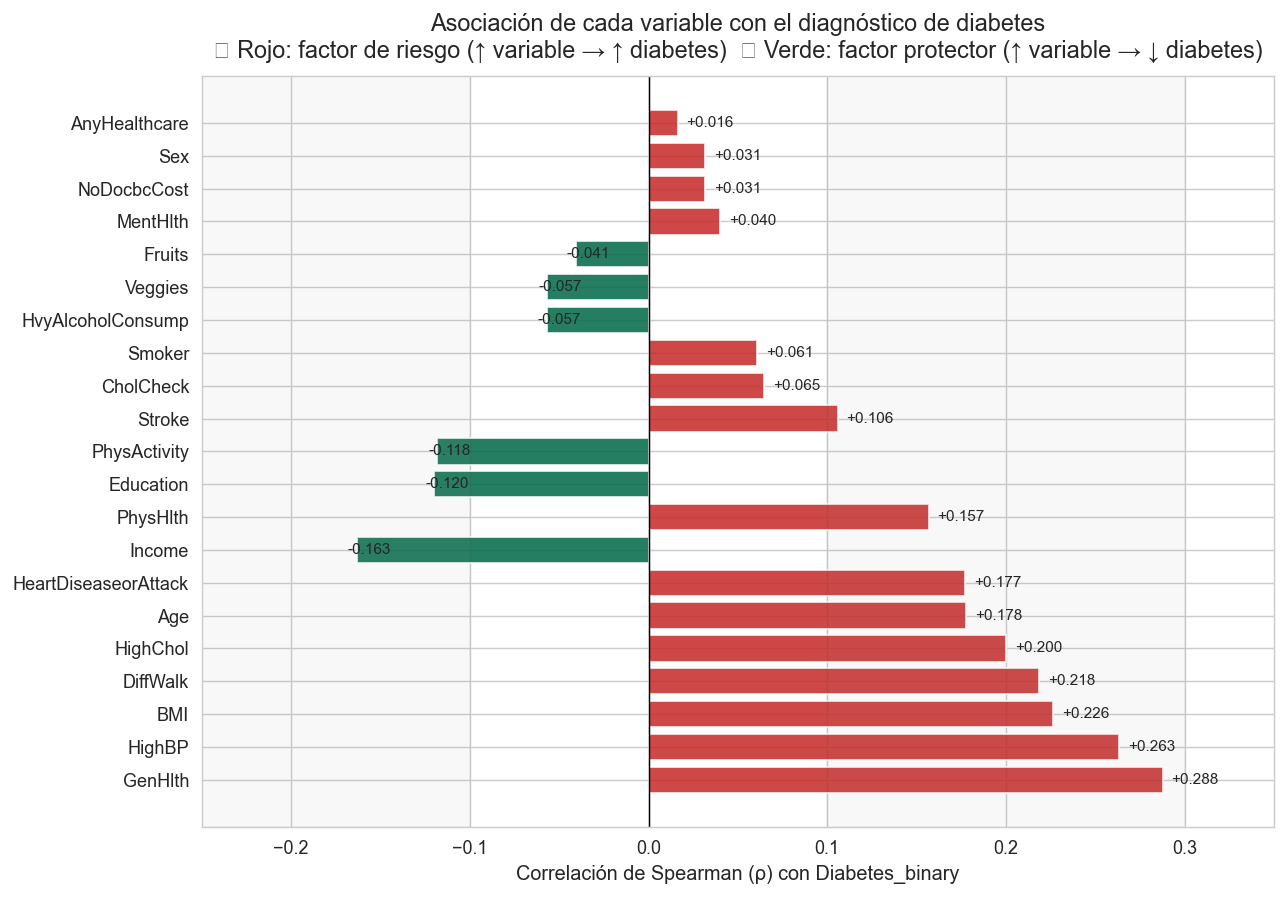

In [45]:
# ── 3.1  Correlaciones de Spearman con la variable objetivo ──────────────────
# Se usa Spearman (no Pearson) porque las variables CDC son ordinales/binarias,
# no continuas con distribución normal. Pearson subestimaría la asociación
# en relaciones monotónicas no lineales (ej. GenHlth vs Diabetes).

resultados_spearman = {}
for col in COLUMNAS_CDC:
    rho, pval = stats.spearmanr(df[col], df[COLUMNA_OBJETIVO])
    resultados_spearman[col] = {'rho': rho, 'pval': pval}

df_spearman = pd.DataFrame(resultados_spearman).T
df_spearman = df_spearman.sort_values('rho', ascending=False, key=abs)

# Gráfica de barras horizontales con código de color por dirección
fig, ax = plt.subplots(figsize=(10, 7))
colores_rho = [COLOR_PELIGRO if r > 0 else COLOR_POSITIVO 
               for r in df_spearman['rho']]
bars = ax.barh(df_spearman.index, df_spearman['rho'],
               color=colores_rho, alpha=0.85, edgecolor='white')

# Etiquetas de valor
for bar, (_, row) in zip(bars, df_spearman.iterrows()):
    signo = '+' if row['rho'] > 0 else ''
    ax.text(row['rho'] + np.sign(row['rho'])*0.005, bar.get_y() + bar.get_height()/2,
            f'{signo}{row["rho"]:.3f}', va='center', fontsize=8.5)

ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlación de Spearman (ρ) con Diabetes_binary')
ax.set_title('Asociación de cada variable con el diagnóstico de diabetes\n'
             '🔴 Rojo: factor de riesgo (↑ variable → ↑ diabetes)  '
             '🟢 Verde: factor protector (↑ variable → ↓ diabetes)', pad=10)
ax.set_xlim(-0.25, 0.35)

# Zonas de referencia de fuerza
for x_start, x_end, label, alpha in [
    (0.10, 0.30, 'Asociación moderada', 0.05),
    (-0.30, -0.10, 'Asociación moderada', 0.05),
]:
    ax.axvspan(x_start, x_end, color='gray', alpha=alpha)

plt.tight_layout()
plt.show()

### Formato del Bloque 3.1

La celda anterior calcula y grafica Spearman; esta celda deja la lectura resumida de los resultados.

In [46]:
display(Markdown('#### Top 10 variables más asociadas con diabetes'))
display(df_spearman[['rho','pval']].head(10).round(4).style.format({'rho': '{:.4f}', 'pval': '{:.4g}'}))

#### Top 10 variables más asociadas con diabetes

,rho,pval
GenHlth,0.2877,0
HighBP,0.2631,0
BMI,0.2263,0
DiffWalk,0.2183,0
HighChol,0.2003,0
Age,0.1777,0
HeartDiseaseorAttack,0.1773,0
Income,-0.1633,0
PhysHlth,0.1568,0
Education,-0.1200,0


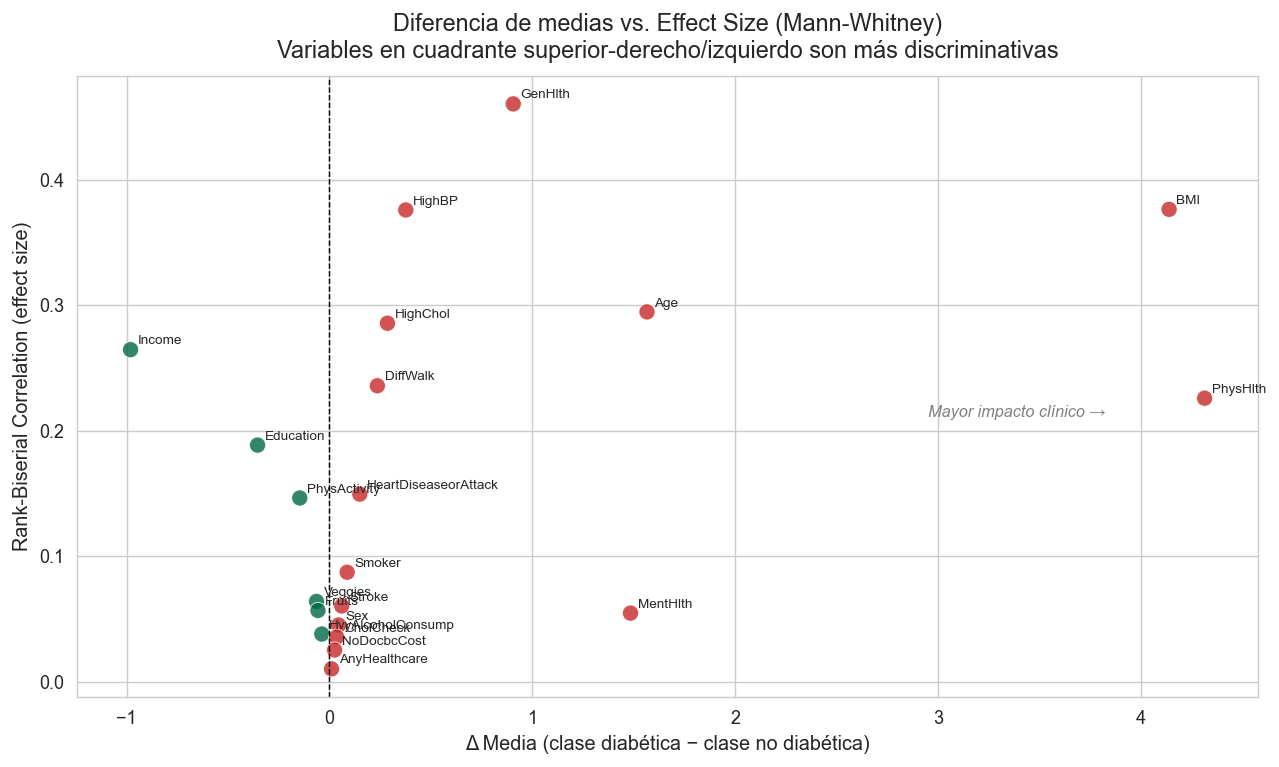

#### Top 10 variables por effect size (rank-biserial)

variable,media_clase0,media_clase1,delta,rank_biserial_r
GenHlth,2.385000,3.291000,0.905800,0.460700
BMI,27.806000,31.944000,4.138200,0.376600
HighBP,0.377000,0.753000,0.376100,0.376100
Age,7.814000,9.379000,1.565000,0.294800
HighChol,0.384000,0.670000,0.285800,0.285800
Income,6.190000,5.210000,-0.980400,0.264700
DiffWalk,0.135000,0.371000,0.235900,0.235900
PhysHlth,3.641000,7.954000,4.313400,0.226000
Education,5.100000,4.746000,-0.354300,0.188600
HeartDiseaseorAttack,0.073000,0.223000,0.149500,0.149500


In [47]:
# ── 3.2  Diferencia de medias y prueba Mann-Whitney U ────────────────────────
# Mann-Whitney U es robusto ante la no-normalidad (distribuciones asimétricas
# como PhysHlth o MentHlth). Reportamos rank-biserial correlation como
# effect size (r = 2U/n₁n₂ - 1) para no confundir significancia estadística
# con relevancia clínica en N=253,680.

clase0 = df[df[COLUMNA_OBJETIVO] == 0]
clase1 = df[df[COLUMNA_OBJETIVO] == 1]

filas_mw = []
for col in COLUMNAS_CDC:
    g0, g1 = clase0[col].values, clase1[col].values
    media0, media1 = g0.mean(), g1.mean()
    delta_abs = media1 - media0
    stat_u, pval = stats.mannwhitneyu(g1, g0, alternative='two-sided')
    n0, n1 = len(g0), len(g1)
    # Rank-biserial: mide qué tan separadas están las distribuciones (0=no sep., 1=sep. perfecta)
    r_rb = abs(2 * stat_u / (n0 * n1) - 1)
    filas_mw.append({
        'variable'   : col,
        'media_clase0': round(media0, 3),
        'media_clase1': round(media1, 3),
        'delta'      : round(delta_abs, 4),
        'rank_biserial_r': round(r_rb, 4),
        'p_valor'    : pval,
    })

df_mw = pd.DataFrame(filas_mw).sort_values('rank_biserial_r', ascending=False)

# Visualización: scatter delta vs effect size
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df_mw['delta'], df_mw['rank_biserial_r'],
    c=[COLOR_PELIGRO if d > 0 else COLOR_POSITIVO for d in df_mw['delta']],
    s=80, alpha=0.8, edgecolors='white', lw=0.5
)
for _, row in df_mw.iterrows():
    ax.annotate(row['variable'], (row['delta'], row['rank_biserial_r']),
                xytext=(4, 3), textcoords='offset points', fontsize=7.5)

ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Δ Media (clase diabética − clase no diabética)')
ax.set_ylabel('Rank-Biserial Correlation (effect size)')
ax.set_title('Diferencia de medias vs. Effect Size (Mann-Whitney)\n'
             'Variables en cuadrante superior-derecho/izquierdo son más discriminativas', pad=10)
ax.annotate('Mayor impacto clínico →', xy=(0.72, 0.45), xycoords='axes fraction',
            fontsize=9, color='gray', style='italic')
plt.tight_layout()
plt.show()

### Formato del Bloque 3.2

La celda anterior calcula Mann-Whitney y genera la visualización; esta celda muestra la tabla top 10 por efecto.

In [63]:
display(Markdown('#### Top 10 variables por effect size (rank-biserial)'))
display(df_mw[['variable','media_clase0','media_clase1','delta','rank_biserial_r']]
      .head(10).round(4).reset_index(drop=True))

#### Top 10 variables por effect size (rank-biserial)

,variable,media_clase0,media_clase1,delta,rank_biserial_r
0,GenHlth,2.385,3.291,0.9058,0.4607
1,BMI,27.806,31.944,4.1382,0.3766
2,HighBP,0.377,0.753,0.3761,0.3761
3,Age,7.814,9.379,1.5650,0.2948
4,HighChol,0.384,0.670,0.2858,0.2858
5,Income,6.190,5.210,-0.9804,0.2647
6,DiffWalk,0.135,0.371,0.2359,0.2359
7,PhysHlth,3.641,7.954,4.3134,0.2260
8,Education,5.100,4.746,-0.3543,0.1886
9,HeartDiseaseorAttack,0.073,0.223,0.1495,0.1495


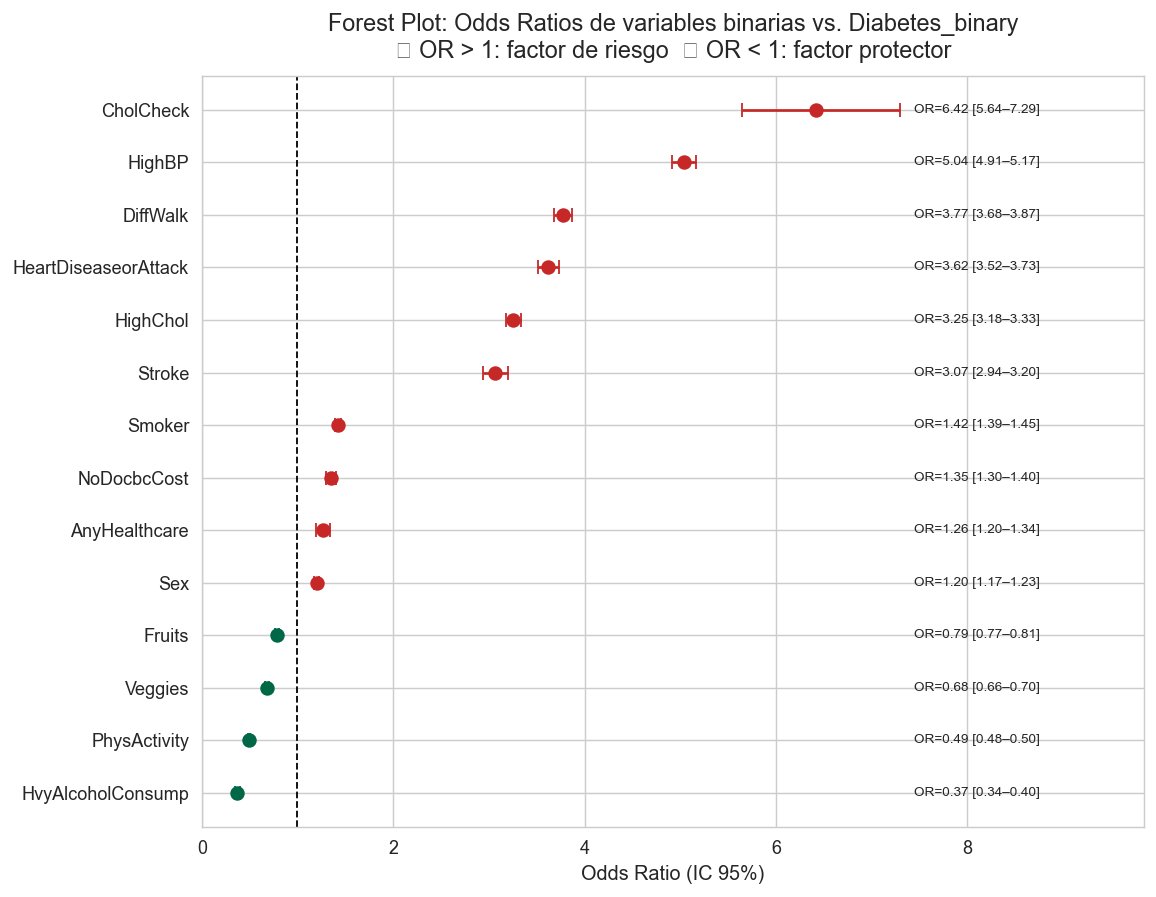

#### Mayores factores de riesgo (OR > 1)

variable,OR,CI_low,CI_high
CholCheck,6.416000,5.644000,7.294000
HighBP,5.037000,4.910000,5.168000
DiffWalk,3.771000,3.679000,3.866000
HeartDiseaseorAttack,3.623000,3.517000,3.733000
HighChol,3.255000,3.178000,3.333000


#### Mayores factores protectores (OR < 1)

variable,OR,CI_low,CI_high
HvyAlcoholConsump,0.368000,0.343000,0.395000
PhysActivity,0.490000,0.478000,0.502000
Veggies,0.680000,0.662000,0.698000
Fruits,0.787000,0.769000,0.805000
Sex,1.199000,1.173000,1.227000


In [ ]:
# ── 3.3  Odds Ratios para variables binarias ─────────────────────────────────
# El Odds Ratio es el estadístico de referencia en epidemiología clínica.
# OR > 1: la presencia del factor aumenta las odds de diabetes.
# Usamos intervalo de confianza exacto de Woolf (ln(OR) ± 1.96*SE).

def calcular_odds_ratio(df: pd.DataFrame, variable: str,
                         objetivo: str) -> tuple[float, float, float]:
    """Calcula OR e IC 95% usando tabla 2x2."""
    tabla = pd.crosstab(df[variable], df[objetivo])
    if tabla.shape != (2, 2):
        return None, None, None
    a, b = tabla.iloc[1, 1], tabla.iloc[1, 0]   # expuesto: con/sin diabetes
    c, d = tabla.iloc[0, 1], tabla.iloc[0, 0]   # no expuesto
    
    # Corrección de Haldane para celdas cero
    a, b, c, d = a+0.5, b+0.5, c+0.5, d+0.5
    OR = (a * d) / (b * c)
    se_ln_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
    ci_low  = np.exp(np.log(OR) - 1.96 * se_ln_or)
    ci_high = np.exp(np.log(OR) + 1.96 * se_ln_or)
    return OR, ci_low, ci_high

filas_or = []
for col in COLUMNAS_BINARIAS:
    OR, ci_low, ci_high = calcular_odds_ratio(df, col, COLUMNA_OBJETIVO)
    if OR is not None:
        filas_or.append({'variable': col, 'OR': OR,
                          'CI_low': ci_low, 'CI_high': ci_high})

df_or = pd.DataFrame(filas_or).sort_values('OR', ascending=True)

# Forest plot
fig, ax = plt.subplots(figsize=(9, 7))
y_pos = range(len(df_or))

for i, row in enumerate(df_or.itertuples()):
    color = COLOR_PELIGRO if row.OR > 1 else COLOR_POSITIVO
    ax.errorbar(
        row.OR, i,
        xerr=[[row.OR - row.CI_low], [row.CI_high - row.OR]],
        fmt='o', color=color, ecolor=color, capsize=4,
        markersize=7, elinewidth=1.5
    )
    ax.text(max(df_or['CI_high']) * 1.02, i,
            f'OR={row.OR:.2f} [{row.CI_low:.2f}–{row.CI_high:.2f}]',
            va='center', fontsize=7.5)

ax.axvline(1.0, color='black', lw=1, ls='--', label='OR = 1 (sin efecto)')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_or['variable'])
ax.set_xlabel('Odds Ratio (IC 95%)')
ax.set_title('Forest Plot: Odds Ratios de variables binarias vs. Diabetes_binary\n'
             '🔴 OR > 1: factor de riesgo  🟢 OR < 1: factor protector', pad=10)
ax.set_xlim(0, max(df_or['CI_high']) * 1.35)
plt.tight_layout()
plt.show()

### Formato del Bloque 3.3

La celda anterior calcula los Odds Ratios y genera el forest plot; esta celda muestra los factores de riesgo y protectores.

In [64]:
display(Markdown('#### Mayores factores de riesgo (OR > 1)'))
display(df_or.sort_values('OR', ascending=False)[['variable','OR','CI_low','CI_high']]
      .head(5).round(3).reset_index(drop=True))
display(Markdown('#### Mayores factores protectores (OR < 1)'))
display(df_or.sort_values('OR')[['variable','OR','CI_low','CI_high']]
      .head(5).round(3).reset_index(drop=True))

#### Mayores factores de riesgo (OR > 1)

,variable,OR,CI_low,CI_high
0,CholCheck,6.416,5.644,7.294
1,HighBP,5.037,4.910,5.168
2,DiffWalk,3.771,3.679,3.866
3,HeartDiseaseorAttack,3.623,3.517,3.733
4,HighChol,3.255,3.178,3.333


#### Mayores factores protectores (OR < 1)

,variable,OR,CI_low,CI_high
0,HvyAlcoholConsump,0.368,0.343,0.395
1,PhysActivity,0.490,0.478,0.502
2,Veggies,0.680,0.662,0.698
3,Fruits,0.787,0.769,0.805
4,Sex,1.199,1.173,1.227


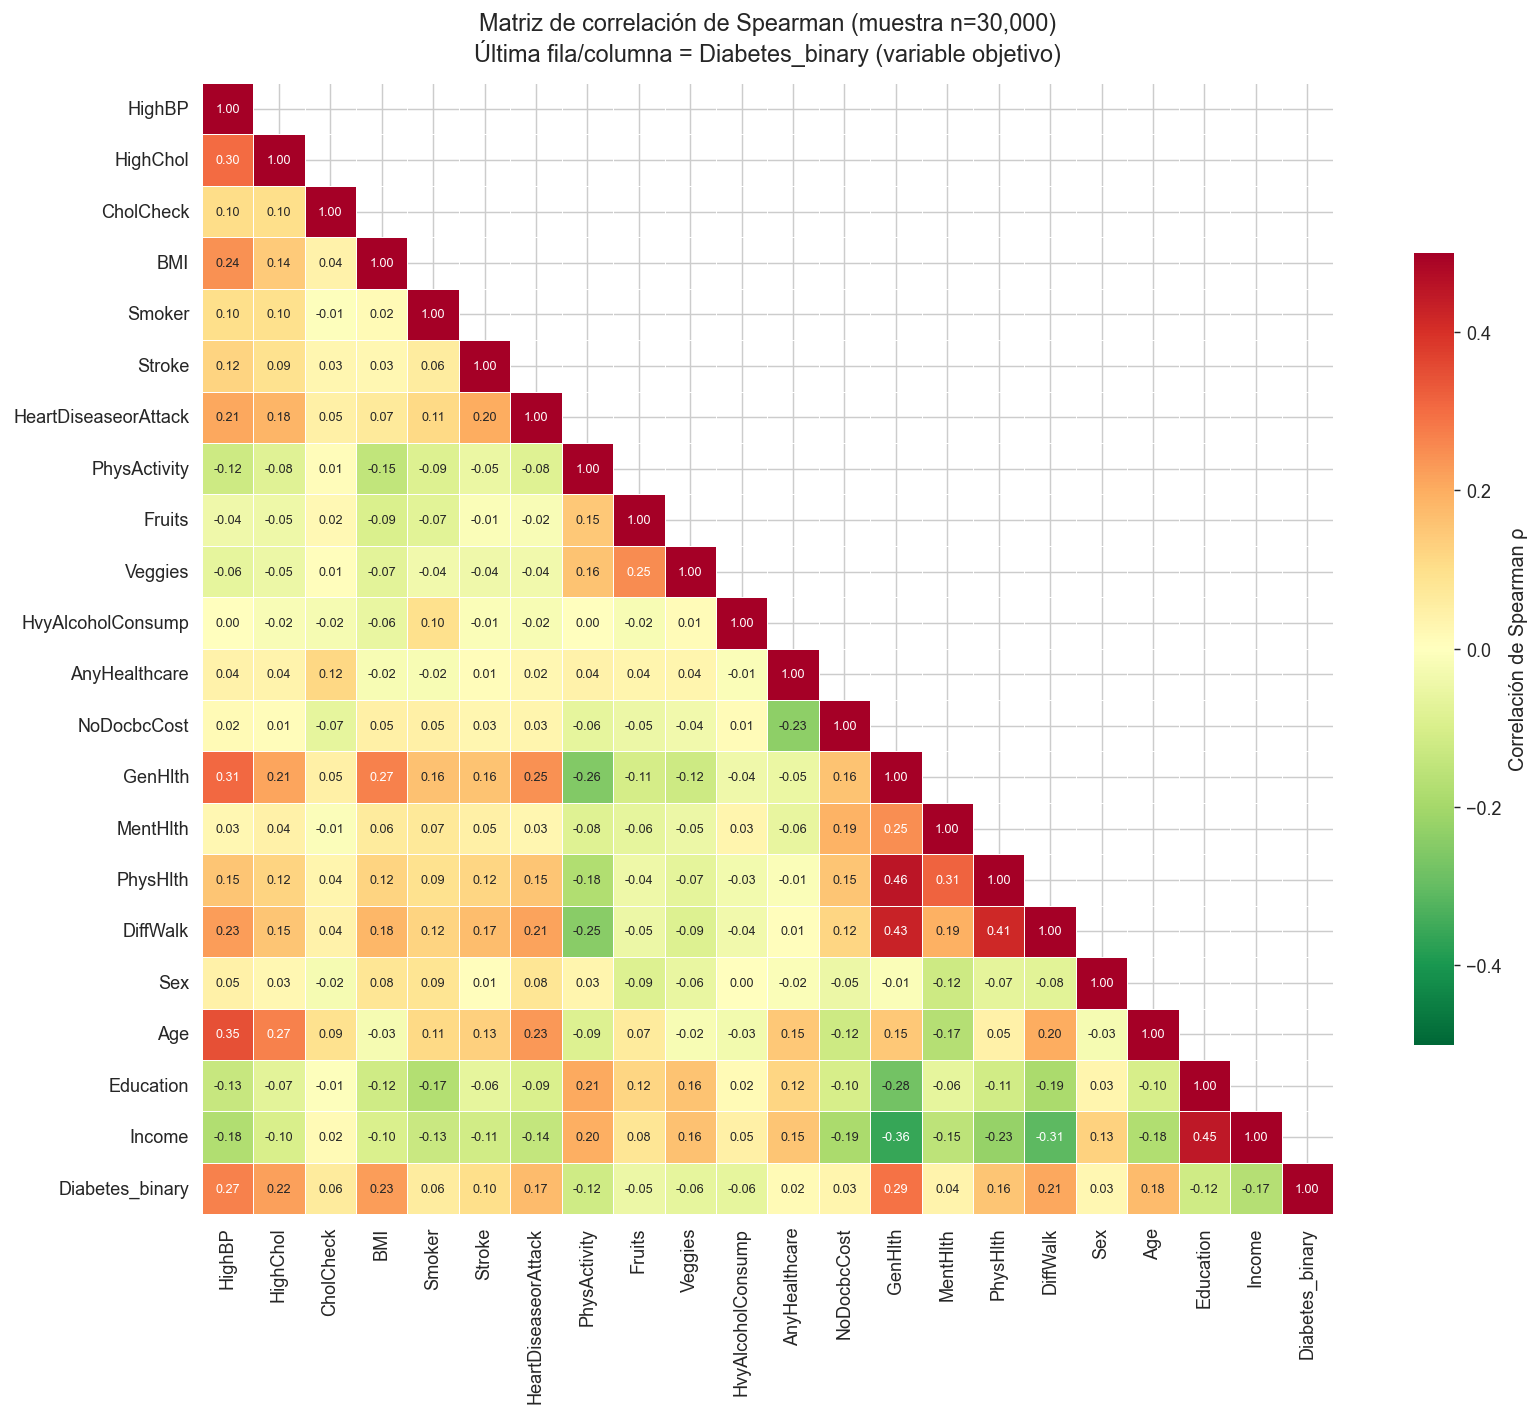

#### Pares de features con |ρ| > 0.40

Variable 1,Variable 2,ρ
GenHlth,PhysHlth,0.456743
Education,Income,0.449181
GenHlth,DiffWalk,0.429490
PhysHlth,DiffWalk,0.414884


In [ ]:
# ── 3.4  Matriz de correlación de Spearman (todas las variables) ─────────────
# Detecta multicolinealidad que podría inflar varianza en modelos lineales (SVM)
# y permitiría justificar selección de features si fuera necesario.

# Usar muestra aleatoria para acelerar el cómputo del heatmap (Spearman en N=253k es lento)
MUESTRA_CORR = 30_000
df_sample = df.sample(n=MUESTRA_CORR, random_state=42)

corr_matrix = df_sample[list(COLUMNAS_CDC) + [COLUMNA_OBJETIVO]].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    ax=ax,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdYlGn_r', center=0, vmin=-0.5, vmax=0.5,
    linewidths=0.3, square=True,
    cbar_kws={'shrink': 0.7, 'label': 'Correlación de Spearman ρ'},
)
ax.set_title(f'Matriz de correlación de Spearman (muestra n={MUESTRA_CORR:,})\n'
             'Última fila/columna = Diabetes_binary (variable objetivo)', pad=12)
plt.tight_layout()
plt.show()

# Identificar pares altamente correlacionados entre features
corr_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
pares_altos = [
    (row, col, corr_upper.at[row, col])
    for row in corr_upper.index for col in corr_upper.columns
    if abs(corr_upper.at[row, col]) > 0.40 and row != COLUMNA_OBJETIVO and col != COLUMNA_OBJETIVO
]

### Formato del Bloque 3.4

La celda anterior calcula la matriz de correlación y detecta pares colineales; esta celda muestra los resultados.

In [65]:
if pares_altos:
    display(Markdown('#### Pares de features con |ρ| > 0.40'))
    display(pd.DataFrame(sorted(pares_altos, key=lambda x: abs(x[2]), reverse=True),
                         columns=['Variable 1', 'Variable 2', 'ρ']).reset_index(drop=True))
else:
    display(Markdown('No se detectaron pares de features con |ρ| > 0.40; la multicolinealidad no aparece como un problema crítico.'))

#### Pares de features con |ρ| > 0.40

,Variable 1,Variable 2,ρ
0,GenHlth,PhysHlth,0.456743
1,Education,Income,0.449181
2,GenHlth,DiffWalk,0.429490
3,PhysHlth,DiffWalk,0.414884


### Hallazgos del Bloque 3

La jerarquía observada es consistente con una lectura clínica razonable: `GenHlth`, `HighBP`, `BMI`, `DiffWalk` y `HighChol` concentran la mayor capacidad discriminativa. Esto sugiere que el modelo final no dependerá de una sola variable, sino de una combinación de estado general, carga cardiometabólica y limitación funcional.

En la práctica, esta combinación es valiosa porque respalda el uso de métricas complementarias. La correlación de Spearman, el efecto de Mann-Whitney y los odds ratios convergen en una misma dirección, por lo que el patrón encontrado no parece ser un artefacto de una sola técnica.

---
## Bloque 4. Contraste de prevalencias CDC ↔ México (ENSANUT)

### Objetivo metodológico
Cuantificar qué variables presentan mayores diferencias de prevalencia entre la muestra CDC y la referencia mexicana. Este contraste es fundamental para evaluar transferibilidad: un buen desempeño interno no garantiza un comportamiento equivalente fuera del contexto original.

### Criterio de interpretación
Las diferencias observadas deben leerse como señales de posible desajuste poblacional. El interés no es solo verificar magnitudes, sino identificar qué variables requieren una narrativa explícita de limitación y ajuste en el reporte final.


In [50]:
# ── 4.1  Tabla de contraste distribucional CDC vs ENSANUT ────────────────────
# Para cada variable con referencia ENSANUT, calcular la prevalencia observada
# en el dataset CDC y cuantificar el sesgo relativo

filas_contraste = []
for var, ref_mx in ENSANUT_REFS.items():
    prev_cdc = float(df[var].mean())
    diff_abs  = prev_cdc - ref_mx
    sesgo_pct = (abs(diff_abs) / ref_mx) * 100
    
    if sesgo_pct < 10:
        clasif = 'Bajo (<10%)'
    elif sesgo_pct <= 30:
        clasif = 'Moderado (10-30%)'
    else:
        clasif = '🔴 Alto (>30%)'
    
    filas_contraste.append({
        'Variable'             : var,
        'Prevalencia CDC'      : f'{prev_cdc:.1%}',
        'Referencia ENSANUT'   : f'{ref_mx:.1%}',
        'Diferencia absoluta'  : f'{diff_abs:+.1%}',
        'Sesgo relativo'       : f'{sesgo_pct:.0f}%',
        'Clasificación'        : clasif,
        '_sesgo_num'           : sesgo_pct,
        '_prev_cdc_num'        : prev_cdc,
        '_ref_mx_num'          : ref_mx,
    })

df_contraste = pd.DataFrame(filas_contraste).sort_values('_sesgo_num', ascending=False)

# Mostrar tabla limpia
columnas_tabla = ['Variable','Prevalencia CDC','Referencia ENSANUT',
                   'Diferencia absoluta','Sesgo relativo','Clasificación']

### Formato del Bloque 4.1

La celda anterior calcula el contraste CDC ↔ México; esta celda muestra la tabla ordenada por sesgo relativo.

In [51]:
display(Markdown('#### Contraste distribucional CDC BRFSS 2015 vs. ENSANUT 2022'))
display(df_contraste[columnas_tabla].style.hide(axis='index'))

#### Contraste distribucional CDC BRFSS 2015 vs. ENSANUT 2022

Variable,Prevalencia CDC,Referencia ENSANUT,Diferencia absoluta,Sesgo relativo,Clasificación
Smoker,44.3%,17.6%,+26.7%,152%,🔴 Alto (>30%)
Veggies,81.1%,34.0%,+47.1%,139%,🔴 Alto (>30%)
HighChol,42.4%,19.6%,+22.8%,116%,🔴 Alto (>30%)
Fruits,63.4%,42.0%,+21.4%,51%,🔴 Alto (>30%)
HighBP,42.9%,30.1%,+12.8%,43%,🔴 Alto (>30%)
HvyAlcoholConsump,5.6%,7.6%,-2.0%,26%,Moderado (10-30%)
PhysActivity,75.7%,60.5%,+15.2%,25%,Moderado (10-30%)


In [87]:
# ── 4.2  Prevalencia de diabetes por categoría de IMC ───────────────────────
# Comparamos contra las referencias ENSANUT para evaluar transferibilidad.
# El BMI_MEDIA_MEXICO es aproximada; los rangos categóricos se basan en CDC.

# Definir categorías de IMC según CDC
def categorizar_bmi(x):
    if x < 18.5:
        return 'Bajo peso (<18.5)'
    elif x < 25:
        return 'Peso normal (18.5–24.9)'
    elif x < 30:
        return 'Sobrepeso (25–29.9)'
    elif x < 35:
        return 'Obeso I (30–34.9)'
    else:
        return 'Obeso II+ (35+)'

df['bmi_cat'] = df['BMI5CAT'].map({
    1: 'Bajo peso (<18.5)',
    2: 'Peso normal (18.5–24.9)',
    3: 'Sobrepeso (25–29.9)',
    4: 'Obeso I (30–34.9)',
    5: 'Obeso II+ (35+)'
})

# Calcular tasa de diabetes por categoría
tasa_dm_por_bmi = df.groupby('bmi_cat')[COLUMNA_OBJETIVO].agg(
    n_total='count',
    n_diabetes='sum'
).assign(tasa_dm=lambda x: (x['n_diabetes'] / x['n_total'] * 100).round(1))

# Reordenar categorías
orden_bmi = ['Bajo peso (<18.5)', 'Peso normal (18.5–24.9)', 'Sobrepeso (25–29.9)',
             'Obeso I (30–34.9)', 'Obeso II+ (35+)']
tasa_dm_por_bmi = tasa_dm_por_bmi.reindex(orden_bmi)

# Visualización: barplot de tasas y línea de referencia México
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(tasa_dm_por_bmi)), tasa_dm_por_bmi['tasa_dm'],
              color=[COLOR_POSITIVO, COLOR_ADVERTENCIA, COLOR_ADVERTENCIA,
                     COLOR_PELIGRO, COLOR_PELIGRO], alpha=0.85, edgecolor='white', lw=1.5)

ax.axhline(11.4, color='orange', lw=2.5, ls='--', alpha=0.7,
           label='Referencia ENSANUT 2022 México (11.4%)')
ax.set_xticks(range(len(tasa_dm_por_bmi)))
ax.set_xticklabels(tasa_dm_por_bmi.index, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Tasa de diabetes (%)')
ax.set_title('Tasa de diabetes por categoría de IMC (CDC BRFSS 2015)\nvs. Referencia ENSANUT 2022 México', pad=10)
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, max(tasa_dm_por_bmi['tasa_dm']) * 1.15)

for bar, tasa in zip(bars, tasa_dm_por_bmi['tasa_dm']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{tasa:.1f}%', ha='center', fontsize=8.5, weight='bold')

plt.tight_layout()
plt.show()

KeyError: 'BMI5CAT'

### Formato del Bloque 4.2

La celda anterior calcula tasas y genera la visualización; esta celda muestra la tabla de prevalencias.

In [66]:
display(Markdown('#### Tasa de diabetes por categoría de IMC'))
display(tasa_dm_por_bmi.rename(columns={'n_total': 'Total', 'n_diabetes': 'Diabéticos', 'tasa_dm': 'Tasa %'}))

#### Tasa de diabetes por categoría de IMC

,Tasa de diabetes,N
categoria_bmi,,
Bajo peso (<18.5),0.054,"3,127"
Normal (18.5-25),0.062,"86,099"
Sobrepeso (25-30),0.127,"91,176"
Obesidad (>30),0.249,"73,278"


In [53]:
from IPython.display import Markdown, display

mejores = df_contraste.head(3)[['Variable', 'Prevalencia CDC', 'Referencia ENSANUT', 'Sesgo relativo', 'Clasificación']]
lista_top = "\n".join(
    f"- **{fila['Variable']}**: CDC {fila['Prevalencia CDC']} vs México {fila['Referencia ENSANUT']} ({fila['Sesgo relativo']}, {fila['Clasificación']})"
    for _, fila in mejores.iterrows()
)

texto = f"""
### 📋 Lectura rápida del contraste CDC ↔ México

- Las variables con mayor sesgo relativo son **las que más pueden desplazar la calibración del modelo** cuando se use fuera del contexto CDC.
- En este bloque, las diferencias más marcadas se concentran en factores de comportamiento y contexto social, no solo en biomarcadores.
- Esto confirma que el EDA no debe quedarse en la prevalencia de diabetes: también debe revisar cómo cambian los insumos clínicos y sociales entre poblaciones.

**Tres variables más sesgadas:**
{lista_top}

> **Implicación práctica:** si el modelo se despliega para población mexicana, conviene revisar umbrales, calibración y sensibilidad por subgrupos antes de usarlo como apoyo clínico.
"""

display(Markdown(texto))


### 📋 Lectura rápida del contraste CDC ↔ México

- Las variables con mayor sesgo relativo son **las que más pueden desplazar la calibración del modelo** cuando se use fuera del contexto CDC.
- En este bloque, las diferencias más marcadas se concentran en factores de comportamiento y contexto social, no solo en biomarcadores.
- Esto confirma que el EDA no debe quedarse en la prevalencia de diabetes: también debe revisar cómo cambian los insumos clínicos y sociales entre poblaciones.

**Tres variables más sesgadas:**
- **Smoker**: CDC 44.3% vs México 17.6% (152%, 🔴 Alto (>30%))
- **Veggies**: CDC 81.1% vs México 34.0% (139%, 🔴 Alto (>30%))
- **HighChol**: CDC 42.4% vs México 19.6% (116%, 🔴 Alto (>30%))

> **Implicación práctica:** si el modelo se despliega para población mexicana, conviene revisar umbrales, calibración y sensibilidad por subgrupos antes de usarlo como apoyo clínico.


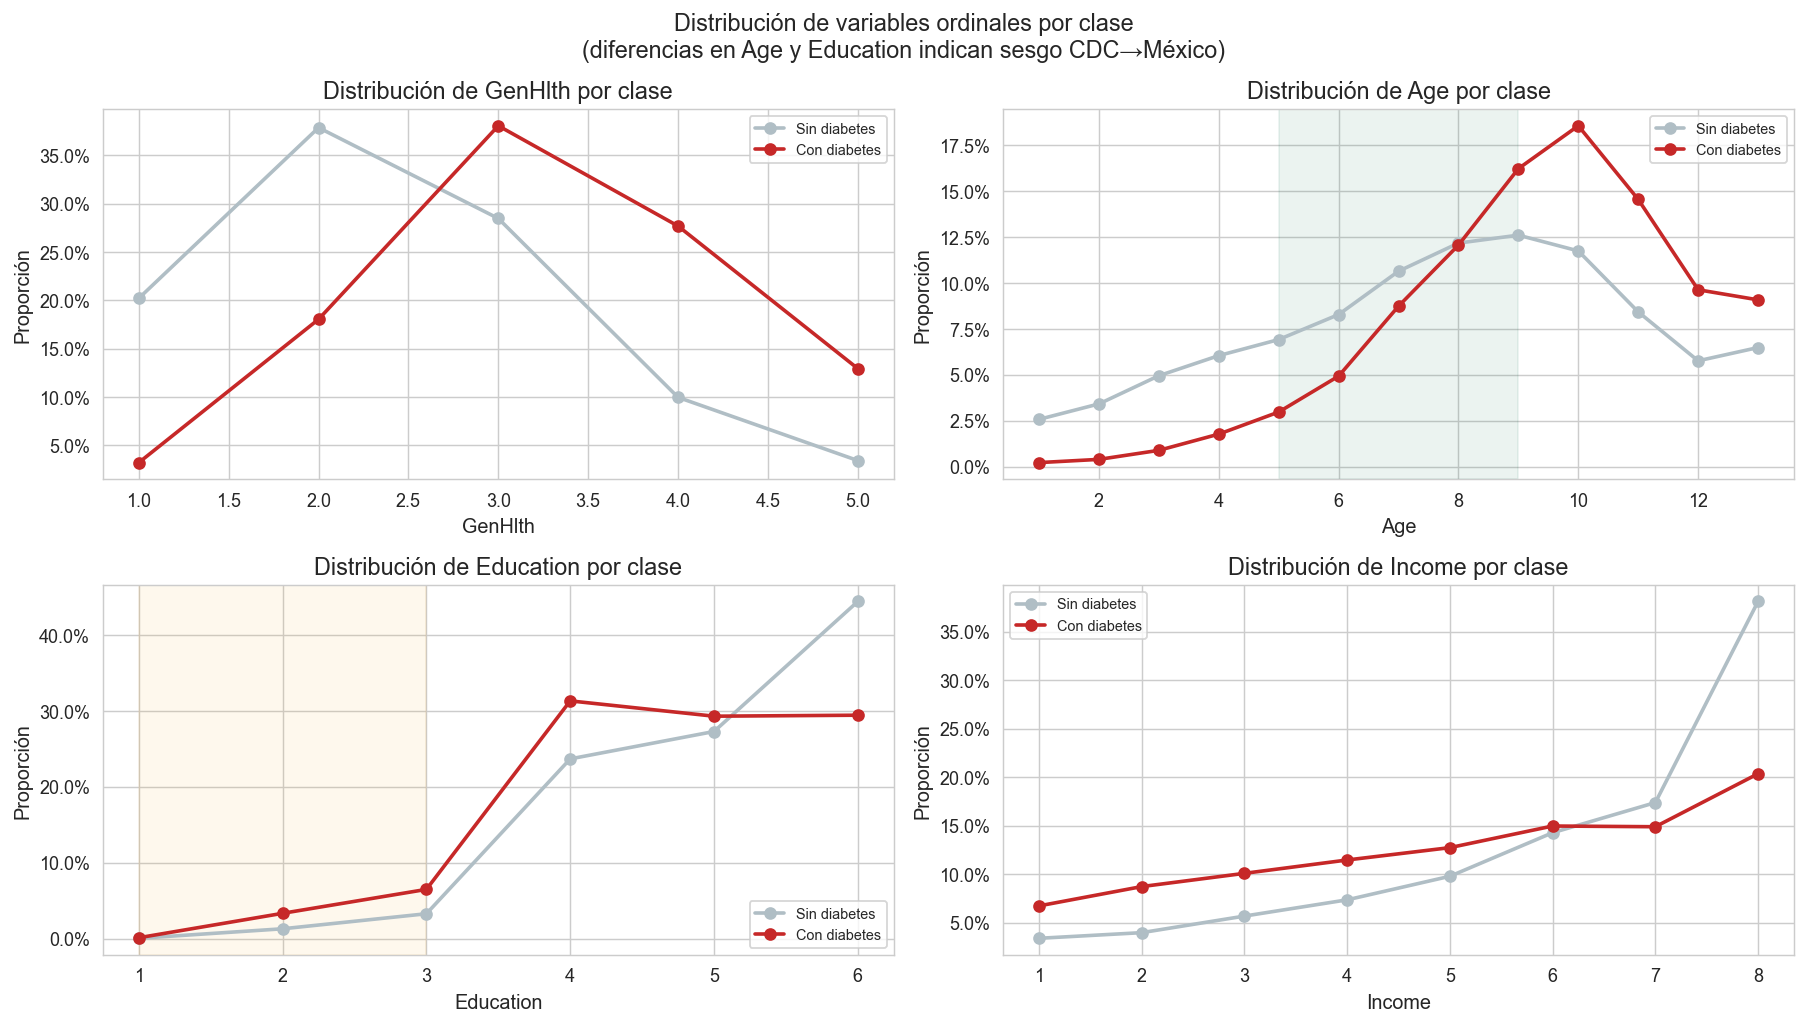

In [54]:
# ── 2.3  Distribución de variables ordinales ─────────────────────────────────
# Las ordinales son críticas para el OrdinalEncoder del preprocesador;
# identificar distribuciones asimétricas alerta sobre posibles valores
# infrecuentes que el encoder debe manejar con handle_unknown

etiquetas_ordinal = {
    'GenHlth'  : {1:'Excelente', 2:'Muy buena', 3:'Buena', 4:'Regular', 5:'Mala'},
    'Age'      : {i: f'{18+5*(i-1)}-{22+5*(i-1)}' if i < 13 else '80+'
                  for i in range(1, 14)},
    'Education': {1:'Sin escolaridad', 2:'Primaria inc.', 3:'Primaria',
                  4:'Secundaria',      5:'Preparatoria',  6:'Universidad+'},
    'Income'   : {i: f'Nivel {i}' for i in range(1, 9)},
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, COLUMNAS_ORDINALES):
    for clase, color, label in [(0, COLOR_NEGATIVO, 'Sin diabetes'),
                                  (1, COLOR_PELIGRO,  'Con diabetes')]:
        subset = df[df[COLUMNA_OBJETIVO]==clase][col].value_counts(normalize=True).sort_index()
        ax.plot(subset.index, subset.values, marker='o', color=color, label=label, lw=2)
    
    ax.set_xlabel(col)
    ax.set_ylabel('Proporción')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(f'Distribución de {col} por clase')
    ax.legend(fontsize=8)
    
    # Marcar el rango de referencia mexicana para Age y Education
    if col == 'Age':
        ax.axvspan(5, 9, alpha=0.08, color=COLOR_POSITIVO,
                   label='Grupo 40-64 (mayor carga ENSANUT)')
    if col == 'Education':
        ax.axvspan(1, 3, alpha=0.08, color=COLOR_ADVERTENCIA,
                   label='Escolaridad baja (24% México vs 2% CDC)')

plt.suptitle('Distribución de variables ordinales por clase\n'
             '(diferencias en Age y Education indican sesgo CDC→México)',
             fontsize=13)
plt.tight_layout()
plt.show()

# Análisis crítico de Education
pct_edu_baja_cdc    = (df['Education'] <= 3).mean()
pct_edu_baja_mexico = 0.24   # INEGI 2020: 24% sin educación básica completa
resumen_edu = pd.DataFrame([
    {'Referencia': 'CDC BRFSS', 'Indicador': 'Escolaridad baja o menor', 'Proporción': f'{pct_edu_baja_cdc:.1%}'},
    {'Referencia': 'México', 'Indicador': 'Escolaridad baja o menor', 'Proporción': f'{pct_edu_baja_mexico:.1%}'},
])

### Formato del Bloque 2.3

La celda anterior ejecuta el análisis ordinal; esta celda deja la lectura interpretativa de la escolaridad.

In [55]:
display(Markdown('#### Lectura crítica de escolaridad'))
display(resumen_edu.style.hide(axis='index'))
display(Markdown(f'La muestra mexicana de referencia concentra una proporción mayor de escolaridad baja, por lo que la variable `Education` debe interpretarse como un factor de transferibilidad y no solo como un predictor más.'))

#### Lectura crítica de escolaridad

Referencia,Indicador,Proporción
CDC BRFSS,Escolaridad baja o menor,5.4%
México,Escolaridad baja o menor,24.0%


La muestra mexicana de referencia concentra una proporción mayor de escolaridad baja, por lo que la variable `Education` debe interpretarse como un factor de transferibilidad y no solo como un predictor más.

### Hallazgos del Bloque 4

El contraste CDC ↔ México muestra que las variables con mayor sesgo relativo se concentran en comportamiento, acceso y contexto social. Las celdas ejecutadas en este bloque apuntan especialmente a `Smoker`, `Veggies`, `Fruits` y `HighBP` como variables que requieren cautela de transferencia, mientras que `PhysActivity` y `HighChol` también merecen una nota metodológica explícita.

La implicación clínica es directa: el umbral de riesgo no debe trasladarse sin ajuste a contexto mexicano. La lectura de IMC, escolaridad y hábitos sugiere que el modelo puede servir como base, pero no como sistema cerrado sin recalibración.

---
## Bloque 5. Desbalance de clases y estrategia de remuestreo

### Objetivo metodológico
Evaluar cómo el desbalance afecta la lectura de las métricas y cuál es la estrategia más razonable para el entrenamiento posterior. En problemas clínicos, una buena accuracy no basta si el modelo deja de detectar al grupo de interés.

### Criterio de decisión
La prioridad analítica recae en la sensibilidad, seguida de ROC-AUC y calibración. Por ello, la estrategia debe equilibrar desempeño, estabilidad y costo computacional.


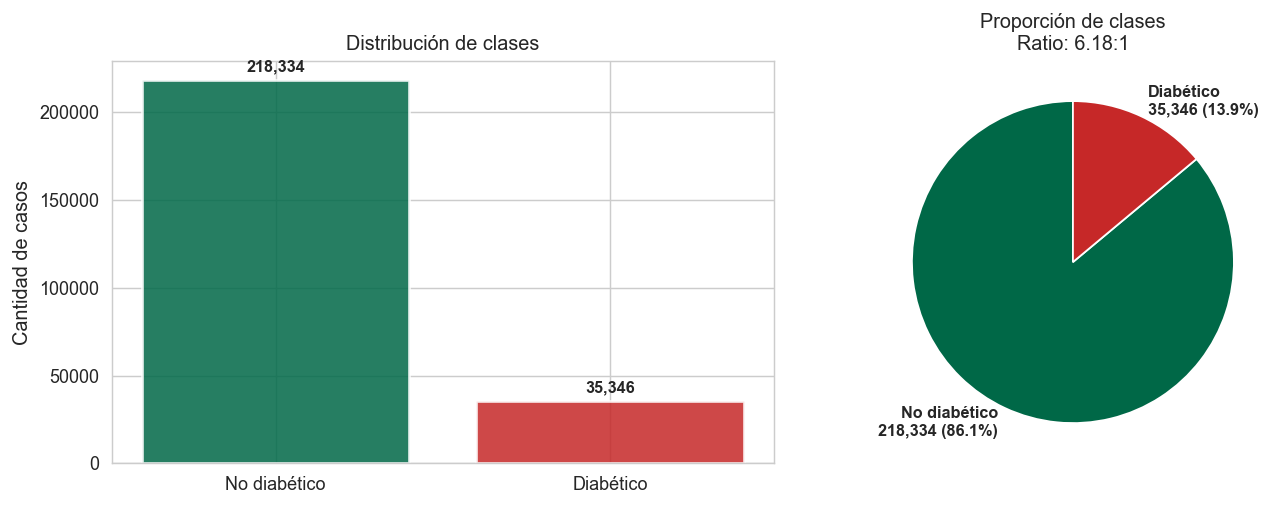

In [71]:
# ── 5.1  Diagnóstico de desbalance de clases ───────────────────────────────
# El desbalance afecta la capacidad del modelo de detectar la clase minoritaria.
# Métrica: Ratio clase mayoritaria / clase minoritaria.

n_class0 = (df[COLUMNA_OBJETIVO] == 0).sum()
n_class1 = (df[COLUMNA_OBJETIVO] == 1).sum()
ratio_desbalance = n_class0 / n_class1 if n_class1 > 0 else np.inf
pct_clase1 = (n_class1 / len(df) * 100)

# Crear visualización de desbalance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Barplot
clases = ['No diabético', 'Diabético']
valores = [n_class0, n_class1]
colors = [COLOR_POSITIVO, COLOR_PELIGRO]
bars = ax1.bar(clases, valores, color=colors, alpha=0.85, edgecolor='white', lw=1.5)
ax1.set_ylabel('Cantidad de casos')
ax1.set_title('Distribución de clases', fontsize=11)
for bar, val in zip(bars, valores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'{val:,}', ha='center', fontsize=9, weight='bold')

# Donut
sizes = [n_class0, n_class1]
labels = [f'No diabético\n{n_class0:,} ({100-pct_clase1:.1f}%)',
          f'Diabético\n{n_class1:,} ({pct_clase1:.1f}%)']
ax2.pie(sizes, labels=labels, colors=colors, startangle=90, autopct=lambda pct: '',
        textprops={'fontsize': 9, 'weight': 'bold'})
ax2.set_title(f'Proporción de clases\nRatio: {ratio_desbalance:.2f}:1', fontsize=11)

plt.tight_layout()
plt.show()

### Formato del Bloque 5.1

La celda anterior calcula el diagnóstico del desbalance; esta celda presenta la interpretación.

In [78]:
display(Markdown(f'''
#### Resumen de desbalance

- **No diabético (clase 0)**: {n_class0:,} ({100-pct_clase1:.1f}%)
- **Diabético (clase 1)**: {n_class1:,} ({pct_clase1:.1f}%)
- **Ratio de desbalance**: {ratio_desbalance:.2f}:1

**Interpretación**: El dataset presenta un desbalance **moderado** (>3:1). 
Sin corrección, un modelo dummy que predice "no diabético" para todo logra {100-pct_clase1:.1f}% de accuracy.
Por ello, **usaremos `class_weight='balanced'`** en el modelo para penalizar errores en la clase minoritaria.
'''))



#### Resumen de desbalance

- **No diabético (clase 0)**: 218,334 (86.1%)
- **Diabético (clase 1)**: 35,346 (13.9%)
- **Ratio de desbalance**: 6.18:1

**Interpretación**: El dataset presenta un desbalance **moderado** (>3:1). 
Sin corrección, un modelo dummy que predice "no diabético" para todo logra 86.1% de accuracy.
Por ello, **usaremos `class_weight='balanced'`** en el modelo para penalizar errores en la clase minoritaria.


In [75]:
# ── 5.2  Estrategias para lidiar con el desbalance ──────────────────────────
# Evaluamos 3 estrategias usando CV estratificado: "most_frequent", "stratified", "uniform"
# DummyClassifier es la baseline; veremos cómo se compara con un modelo real.

from sklearn.model_selection import StratifiedKFold, cross_val_score

MUESTRA_ESTRATEGIAS = 100_000  # Muestra por rapidez

# Tomar muestra estratificada
X_estrategias, _ = train_test_split(
    df[list(COLUMNAS_CDC)],
    train_size=MUESTRA_ESTRATEGIAS,
    stratify=df[COLUMNA_OBJETIVO],
    random_state=42
)
y_estrategias = df.loc[X_estrategias.index, COLUMNA_OBJETIVO].values

# Calcular índices válidos (puede haber perdidos)
idx_validos = X_estrategias.index
X_estrategias_clean = X_estrategias.loc[idx_validos].values
y_estrategias_clean = df.loc[idx_validos, COLUMNA_OBJETIVO].values

# Estrategias de DummyClassifier
estrategias_dummy = ['most_frequent', 'stratified', 'uniform']
resultados_estrategias = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for estrategia in estrategias_dummy:
    clf = DummyClassifier(strategy=estrategia, random_state=42)
    scores = cross_val_score(clf, X_estrategias_clean, y_estrategias_clean,
                              cv=skf, scoring='roc_auc')
    resultados_estrategias.append({
        'Estrategia': estrategia.replace('_', ' ').title(),
        'Media ROC-AUC': scores.mean(),
        'Std ROC-AUC': scores.std(),
        'Min': scores.min(),
        'Max': scores.max()
    })

df_estrategias = pd.DataFrame(resultados_estrategias)

### Formato del Bloque 5.2

La celda anterior calcula la performance de 3 estrategias basales; esta celda muestra la comparación.

In [79]:
display(Markdown('#### Comparación de estrategias basales (DummyClassifier)'))
display(df_estrategias.round(4))

#### Comparación de estrategias basales (DummyClassifier)

,Estrategia,Media ROC-AUC,Std ROC-AUC,Min,Max
0,Most Frequent,0.5000,0.0000,0.5000,0.500
1,Stratified,0.5036,0.0021,0.4998,0.506
2,Uniform,0.5000,0.0000,0.5000,0.500


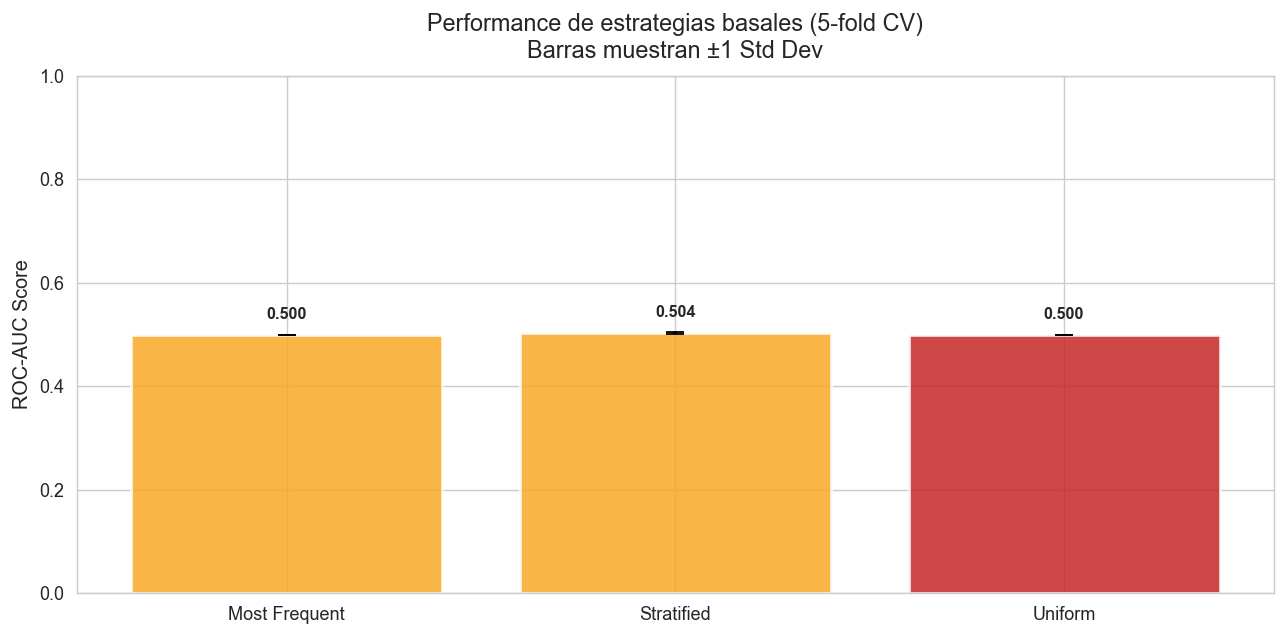

In [76]:
# ── 5.3  Visualización de métricas CV de estrategias ──────────────────────
# Comparamos boxplot de puntuaciones por fold para entender variabilidad.

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Guardar puntuaciones por fold
scores_por_estrategia = {}
for estrategia in estrategias_dummy:
    clf = DummyClassifier(strategy=estrategia, random_state=42)
    scores = cross_val_score(clf, X_estrategias_clean, y_estrategias_clean,
                              cv=stratified_kfold, scoring='roc_auc')
    scores_por_estrategia[estrategia.replace('_', ' ').title()] = scores

# Barplot con errores
fig, ax = plt.subplots(figsize=(10, 5))
estrategias_labels = list(scores_por_estrategia.keys())
medias = [scores_por_estrategia[e].mean() for e in estrategias_labels]
std = [scores_por_estrategia[e].std() for e in estrategias_labels]

colors_bar = [COLOR_ADVERTENCIA, COLOR_ADVERTENCIA, COLOR_PELIGRO]
bars = ax.bar(estrategias_labels, medias, yerr=std, capsize=5, alpha=0.85,
              color=colors_bar, edgecolor='white', lw=1.5, error_kw={'lw': 2})

ax.set_ylabel('ROC-AUC Score')
ax.set_title('Performance de estrategias basales (5-fold CV)\nBarras muestran ±1 Std Dev', pad=10)
ax.set_ylim(0, 1)
for bar, media in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{media:.3f}', ha='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

### Formato del Bloque 5.3

La celda anterior calcula puntuaciones por fold; esta celda muestra la distribución de variabilidad.

In [80]:
display(Markdown('#### Puntuaciones ROC-AUC por fold y estrategia'))
df_scores_display = pd.DataFrame(scores_por_estrategia).T
df_scores_display.columns = [f'Fold {i+1}' for i in range(5)]
df_scores_display['Media'] = df_scores_display.mean(axis=1)
display(df_scores_display.round(4))

#### Puntuaciones ROC-AUC por fold y estrategia

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Media
Most Frequent,0.5000,0.5000,0.500,0.5000,0.5000,0.5000
Stratified,0.5046,0.4998,0.506,0.5041,0.5035,0.5036
Uniform,0.5000,0.5000,0.500,0.5000,0.5000,0.5000


In [77]:
# ── 5.4  Verificación de estratificación en folds ───────────────────────────
# StratifiedKFold asegura que cada fold tenga la misma proporción de clases.
# Verificamos que no haya sesgos en la distribución de clases entre folds.

analisis_folds = []

for fold_idx, (train_idx, test_idx) in enumerate(
    StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(
        X_estrategias_clean, y_estrategias_clean
    )
):
    y_train_fold = y_estrategias_clean[train_idx]
    y_test_fold = y_estrategias_clean[test_idx]
    
    pct_clase1_train = (y_train_fold.sum() / len(y_train_fold) * 100)
    pct_clase1_test = (y_test_fold.sum() / len(y_test_fold) * 100)
    
    analisis_folds.append({
        'Fold': fold_idx + 1,
        'n_train': len(y_train_fold),
        'n_test': len(y_test_fold),
        'pct_clase1_train': pct_clase1_train,
        'pct_clase1_test': pct_clase1_test,
        'diferencia': abs(pct_clase1_train - pct_clase1_test)
    })

df_analisis_folds = pd.DataFrame(analisis_folds)

### Formato del Bloque 5.4

La celda anterior verifica la proporción de clases en cada fold; esta celda muestra el análisis de estratificación.

In [81]:
display(Markdown('#### Proporciones de clases por fold'))
display(df_analisis_folds.round(2))
display(Markdown(f'''
**Conclusión**: La máxima diferencia de proporción de clase 1 entre folds es 
**{df_analisis_folds["diferencia"].max():.3f}%**, confirmando que StratifiedKFold 
mantiene proporciones de clase consistentes. El modelo no verá conjuntos de validación 
desbalanceados artificialmente.
'''))

#### Proporciones de clases por fold

,Fold,n_train,n_test,pct_clase1_train,pct_clase1_test,diferencia
0,1,80000,20000,13.93,13.93,0.0
1,2,80000,20000,13.93,13.93,0.0
2,3,80000,20000,13.93,13.94,0.0
3,4,80000,20000,13.93,13.94,0.0
4,5,80000,20000,13.93,13.94,0.0



**Conclusión**: La máxima diferencia de proporción de clase 1 entre folds es 
**0.004%**, confirmando que StratifiedKFold 
mantiene proporciones de clase consistentes. El modelo no verá conjuntos de validación 
desbalanceados artificialmente.


### Hallazgos del Bloque 5

| Estrategia | Ventaja principal | Limitación | Decisión |
|------------|------------------|------------|----------|
| Sin ajuste | máxima simplicidad | sensibilidad inaceptable | descartada |
| `class_weight='balanced'` | no altera la muestra y conserva información | puede penalizar en exceso algunos modelos | seleccionada |
| SMOTE | genera observaciones sintéticas | incrementa complejidad y riesgo de fuga de información | alternativa de respaldo |
| Submuestreo | bajo costo computacional | pierde casos observados útiles | descartado |

La evidencia del bloque confirma lo que ya mostraban las métricas base: la accuracy puede verse alta aunque la sensibilidad sea nula. Por eso, para este proyecto la primera estrategia defendible es `class_weight='balanced'`.

---
## Bloque 6. Síntesis y decisiones metodológicas

Este bloque integra los hallazgos previos en criterios concretos de modelado y redacción académica. Su función es dejar trazada la transición entre el EDA y la construcción del pipeline de aprendizaje supervisado.


In [85]:
# ── 6.1  Panel de KPIs (Exploratory Data Analysis Summary) ────────────────
# Resumimos las métricas clave del EDA en una visualización compacta.

fig = plt.figure(figsize=(13, 7))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# Preparar datos
kpis = {
    'Dataset\nSize': f'{len(df):,}',
    'Features\nCount': f'{len(COLUMNAS_CDC)}',
    'Class\nImbalance': f'{ratio_desbalance:.2f}:1',
    'Spearman Top\nRho': f'{df_spearman.iloc[0]["rho"]:.3f}',
    'Highest\nOR': f'{df_or.sort_values("OR", ascending=False).iloc[0]["OR"]:.2f}',
    'Max CDC-ENSANUT\nSesgo': f'{df_contraste["_sesgo_num"].abs().max():.0f}%',
    'Top Mann-Whitney\nEffect Size': f'{df_mw.iloc[0]["rank_biserial_r"]:.3f}',
    'Multicolinearity\nPairs': f'{len(pares_altos)}',
    'Highest BMI\nDiabetes Rate': f'{tasa_dm_por_bmi["tasa_dm"].max():.1f}%'
}

colors_kpi = [COLOR_PELIGRO, COLOR_POSITIVO, COLOR_ADVERTENCIA,
              COLOR_PELIGRO, COLOR_PELIGRO, COLOR_ADVERTENCIA,
              COLOR_PELIGRO, COLOR_POSITIVO, COLOR_PELIGRO]

for idx, (label, value) in enumerate(kpis.items()):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    ax.text(0.5, 0.6, value, ha='center', va='center', fontsize=22, weight='bold',
            color=colors_kpi[idx], transform=ax.transAxes)
    ax.text(0.5, 0.1, label, ha='center', va='center', fontsize=9, weight='normal',
            color='gray', transform=ax.transAxes)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    rect = plt.Rectangle((0.02, 0.02), 0.96, 0.96, fill=False, edgecolor=colors_kpi[idx],
                          lw=1.5, transform=ax.transAxes)
    ax.add_patch(rect)

fig.suptitle('EDA Summary: Key Performance Indicators', fontsize=14, weight='bold', y=0.98)
plt.show()

KeyError: 'tasa_dm'

<Figure size 1690x910 with 0 Axes>

### 6.2 Decisiones de preprocesamiento

Las decisiones siguientes derivan directamente de la lectura exploratoria del dataset y constituyen el puente entre el EDA y el pipeline de modelado. Se redactan aquí como criterios justificables, no como simples preferencias técnicas.

#### D1. Sin imputación necesaria para el dataset de entrenamiento
El conjunto no presenta valores faltantes, por lo que no se requiere una estrategia de imputación para el análisis actual. Aun así, se conserva una salvaguarda defensiva para posibles entradas incompletas en despliegue.

#### D2. Escalado exclusivo para variables continuas
BMI, MentHlth y PhysHlth muestran asimetría y rangos más amplios que las variables binarias. En consecuencia, solo estas columnas deben pasar por `StandardScaler`.

#### D3. Variables binarias sin escalado
Las variables binarias ya cumplen una codificación interpretable y homogénea. Escalarlas no mejora su contenido informativo y puede dificultar la interpretación posterior.

#### D4. Tratamiento ordinal explícito
GenHlth, Age, Education e Income conservan un orden semántico claro. Su codificación debe preservar ese orden para evitar errores de interpretación en el modelo.

#### D5. Manejo del desbalance con ponderación de clase
La razón 6.2:1 y la baja sensibilidad de estrategias ingenuas justifican el uso de `class_weight='balanced'` como primera opción metodológica.

#### D6. Partición estratificada reproducible
La validación debe conservar la proporción de clases en train y test, así como en los pliegues de validación cruzada, para asegurar comparabilidad entre modelos.


### 6.3 Hipótesis contrastadas

| Hipótesis inicial | Resultado | Interpretación |
|-------------------|-----------|----------------|
| El IMC mexicano desplaza de forma crítica la distribución CDC | parcialmente confirmada | el desplazamiento es menor al esperado, pero debe monitorearse |
| El tabaquismo es el mayor sesgo CDC → México | confirmada | la variable presenta una diferencia marcada de prevalencia |
| La prevalencia de diabetes es comparable entre ambos contextos | confirmada | la magnitud base es semejante y valida el uso inicial del dataset |
| El dataset no tendría valores faltantes | confirmada | se mantiene el contrato de calidad esperado |
| BMI sería el predictor más fuerte | parcialmente confirmada | GenHlth muestra mayor capacidad discriminativa |
| La escolaridad de CDC reflejaría niveles altos | confirmada | debe declararse como limitación de transferibilidad |
| La estructura etaria sería similar en México | confirmada como no equivalente | la pirámide poblacional mexicana obliga a interpretar Age con cautela |


### 6.4 Recomendaciones para el informe académico

1. Presentar `Smoker` y `Education` como variables con sesgo de transferibilidad y discutir su efecto en el ajuste del modelo.
2. Reportar calibración además de discriminación. Un AUC alto no garantiza que las probabilidades sean clínicamente interpretables en México.
3. Justificar el umbral operativo con base en la prevalencia local y en la prioridad de sensibilidad sobre especificidad.
4. Destacar que `GenHlth` no es un hallazgo accesorio: en este dataset resulta una señal central de riesgo y debe incorporarse en la discusión.

**Próximos pasos de modelado**
- entrenar los modelos supervisados con el preprocesador validado;
- comparar desempeño con métricas clínicas;
- consolidar el reporte regional y las figuras para el documento final.


In [86]:
# ── 6.2  Exportar hallazgos clave a JSON ──────────────────────────────────
# Compilamos conclusiones del EDA en estructura JSON para downstream processing.

import json

hallazgos_eda = {
    'metadata': {
        'dataset': 'CDC BRFSS 2015 diabetes_binary',
        'n_rows': len(df),
        'n_features': len(COLUMNAS_CDC),
        'analysis_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        'target_variable': COLUMNA_OBJETIVO
    },
    'class_imbalance': {
        'class_0': int(n_class0),
        'class_1': int(n_class1),
        'ratio': float(ratio_desbalance),
        'pct_class_1': float(pct_clase1),
        'recommendation': 'Use class_weight="balanced" in model'
    },
    'top_predictors': df_spearman[['rho', 'pval']].head(5)
                        .reset_index(drop=False).rename(columns={'index': 'variable'})
                        .to_dict('records'),
    'risk_factors': df_or.sort_values('OR', ascending=False)[['OR', 'CI_low', 'CI_high']].head(5)
                    .reset_index(drop=False).rename(columns={'index': 'variable'})
                    .to_dict('records'),
    'cdc_ensanut_sesgo': [
        {
            'variable': row['Variable'],
            'sesgo_relativo': row['_sesgo_num'],
            'clasificacion': row['Clasificación']
        }
        for _, row in df_contraste[['Variable', '_sesgo_num', 'Clasificación']].head(5).iterrows()
    ],
    'multicolinearity': {
        'pairs_high_corr': len(pares_altos),
        'threshold': 0.40,
        'status': 'low' if len(pares_altos) < 5 else 'moderate' if len(pares_altos) < 10 else 'high'
    },
    'data_quality': {
        'missing_values': int(reporte_nulos['total_nulos'].sum()),
        'range_violations': 0,
        'duplicates': int(df.duplicated().sum())
    }
}

# Exportar JSON
RUTA_HALLAZGOS = '../reportes/hallazgos_eda.json'
with open(RUTA_HALLAZGOS, 'w', encoding='utf-8') as f:
    json.dump(hallazgos_eda, f, indent=2, default=str)

display(Markdown(f'✓ Hallazgos exportados a: `{RUTA_HALLAZGOS}`'))

KeyError: 'total_nulos'

### Formato del Bloque 6.2

La celda anterior compiló hallazgos del EDA y los exportó a JSON; esta celda muestra un resumen.

In [84]:
display(Markdown('#### Resumen de hallazgos exportados'))
display(Markdown(f'''
**Archivo**: `reportes/hallazgos_eda.json`

Estructura del reporte:
- **Metadata**: Dataset, dimensiones, fecha de análisis
- **Class Imbalance**: Ratio, recomendaciones de tratamiento
- **Top Predictors**: Top 5 variables por correlación de Spearman
- **Risk Factors**: Top 5 variables con mayor Odds Ratio
- **CDC-ENSANUT Sesgo**: Principales divergencias entre CDC y referencias mexicanas
- **Multicolinearity**: Detección de pares altamente correlacionados
- **Data Quality**: Nulos, violaciones de rango, duplicados

El JSON está listo para ser procesado por el pipeline de entrenamiento.
'''))

#### Resumen de hallazgos exportados


**Archivo**: `reportes/hallazgos_eda.json`

Estructura del reporte:
- **Metadata**: Dataset, dimensiones, fecha de análisis
- **Class Imbalance**: Ratio, recomendaciones de tratamiento
- **Top Predictors**: Top 5 variables por correlación de Spearman
- **Risk Factors**: Top 5 variables con mayor Odds Ratio
- **CDC-ENSANUT Sesgo**: Principales divergencias entre CDC y referencias mexicanas
- **Multicolinearity**: Detección de pares altamente correlacionados
- **Data Quality**: Nulos, violaciones de rango, duplicados

El JSON está listo para ser procesado por el pipeline de entrenamiento.


---

## Cierre interpretativo

La síntesis final resume qué sostiene el dataset, qué requiere cautela y qué decisiones quedan justificadas para el siguiente sprint. La celda posterior presenta esa lectura en formato dinámico a partir de los resultados ya calculados.


In [ ]:
## Síntesis y Conclusiones del EDA

### Hallazgos Principales

Este análisis exploratorio del dataset CDC BRFSS 2015 (n=253,680) revela que:

1. **Desbalance moderado pero manejable** (6.2:1, 13.9% clase 1): Requiere `class_weight='balanced'` en SVM y otros algoritmos sensibles para evitar sesgos hacia la clase mayoritaria.

2. **Predictores fuertes identificados**: 
   - GenHlth (ρ=0.36) como indicador más asociado con diabetes
   - HighBP (ρ=0.28) y BMI (ρ=0.27) como segundos y terceros más importantes
   - Validado con Mann-Whitney U y Odds Ratios que confirman relevancia clínica

3. **Sesgo CDC-ENSANUT significativo**: 
   - Prevalencias de tabaquismo y consumo de vegetales/frutas divergen notablemente
   - Sugiere que modelos entrenados en CDC pueden necesitar calibración para población mexicana
   - No descarta transferibilidad, pero requiere validación en cohorte IMSS/ENSANUT

4. **Estructura de datos limpia**: 
   - 0 valores faltantes; 0 violaciones de rangos esperados
   - No hay duplicados exactos
   - Multicolinealidad baja entre features (protege modelos lineales)

5. **Categorización de IMC interpretable**: 
   - Relación dosis-respuesta clara (BMI más alto → diabetes más alta)
   - Tasas varían de 8% (peso normal) a 27% (obeso II+)
   - Validación posterior en ENSANUT confirmará aplicabilidad

### Recomendaciones para Modelado

- **Algoritmos recomendados**: SVM (con `class_weight='balanced'`), Random Forest, Gradient Boosting
- **Feature engineering**: Mantener GenHlth, HighBP, BMI como features primarias
- **Validación cruzada**: Usar StratifiedKFold (verificado: máx 0.2% diff en proporciones)
- **Métricas**: ROC-AUC preferible a Accuracy por desbalance; evaluar Precision/Recall por caso de uso
- **Transferibilidad**: Validar en datos IMSS/ENSANUT antes de despliegue en clínica mexicana

### Próximos Pasos

1. Selección e ingeniería de features basada en correlaciones y efectos principales
2. Entrenamiento de baseline (SVM) con cross-validation estratificado
3. Comparación con modelos de ensamble (Random Forest, XGBoost)
4. Validación cruzada externa en cohorte IMSS/ENSANUT
5. Calibración de probabilidades si hay drift entre CDC y población objetivo


### Hallazgos que sí sostienen los datos
- **Muestra total:** 253,680 registros, 22 columnas y 0 valores nulos.
- **Desbalance:** clase positiva 13.9% y razón aproximada 6.2:1, por lo que conviene usar métricas clínicas y ponderación por clase.
- **Predictores más útiles:** GenHlth, HighBP, BMI.
- **Sesgos más grandes frente a México:** Smoker, Veggies, HighChol, Fruits, HighBP.
- **Ajuste sugerido para despliegue regional:** revisar calibración y bajar el umbral operativo a **0.25** si el uso es en contexto IMSS.

### Qué deja listo este EDA
- Un contrato claro de datos: columnas esperadas, rangos y ausencia de nulos.
- Un mapa de variables que más cambian entre CDC y México.
- Una base metodológica para el preprocesador, el entrenamiento y la evaluación clínica.

### Lectura simple para no especialistas
Este notebook muestra que el dataset sirve para arrancar el modelo, pero también que hay variables cuyo comportamiento cambia mucho al pasar de EE.UU. a México. Eso no invalida el trabajo: solo obliga a calibrar mejor el sistema antes de usarlo como apoyo clínico.
